# Analyse Exploratoire
**Contexte**
Objectif : prédire *la consommation totale d’énergie* et *les émissions de CO₂* de bâtiments **non résidentiels** à Seattle à partir de leurs caractéristiques structurelles (surface, usages, ancienneté, localisation…), en s’appuyant sur les relevés 2016.

### Candidats target
- **prédire la consommation totale d’énergie de bâtiments:** `SiteEnergyUse(kBtu)`

  La quantité annuelle d'énergie consommée par le bien, toutes sources d'énergie confondues.
  Unité utilisée : **kBtu** = Kilo British Thermal Units / Kilo d'unités thermiques britanniques

- **prédire les émissions de CO₂**: `TotalGHGEmissions`

   La quantité totale d'émission de gaz à effet de serre, y compris le dioxyde de carbone, le méthane et l'oxyde nitreux,
   rejetée dans   l'atmosphère à la suite de la consommation d'énergie sur le site, mesurée en tonne d'équivalent dioxyde de carbone.


**Candidats target**
  
- **prédire la consommation totale d’énergie de bâtiments:** `SiteEnergyUse(kBtu)`

- **prédire les émissions de CO₂**: `TotalGHGEmissions`


### Import des modules

In [946]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


### 1.1 Analyse Exploratoire

In [947]:
df = pd.read_csv('2016_Building_Energy_Benchmarking.csv')

In [948]:
# On regarde comment un batiment est défini dans ce jeu de données 
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


### Colonnes gardées

- **Structure** : `PropertyGFATotal`, `PropertyGFAParking`, `PropertyGFABuilding(s)`, `YearBuilt`, `NumberofBuildings`, `NumberofFloors`, 
  décrivent la taille et la morphologie du bâtiment.

- **Usage** : `PrimaryPropertyType`, `Largest/Second/ThirdPropertyUseType + leurs `GFA`
   distinguent mono-usage vs multi-usages, clé pour expliquer la variabilité énergétique.

- **Localisation** : `OSEBuildingID`, `Neighborhood`,`Latitude`, `Longitude`
  utiles pour jointures, contrôle de périmètre.

- **Énergie par vecteur** (indicatives, souvent manquantes) : `SiteEnergyUse(kBtu)`, `SiteEnergyUseWN(kBtu)`, `SiteEUI(kBtu/sf)`, `TotalGHGEmissions`, `GHGEmissionsIntensity`, et vecteurs (`Electricity(kWh), NaturalGas(therms), SteamUse(kBtu))`

**Vocabulaire métier:**

les acronymes utilisés dans les colonnes:

**GHG**: greenhouse gas emissions, correspond aux émissions des gazs à effets de serre.

**OSE**: Seattle Office of Sustainability and Environment.

**EUI**: Energy Use Intensity.

**kBtu**: kilo-British thermal unit, 1 kWh = 3.412 kBtu.

**sf**: square feet, 1m² = 10,7639sf.

**WN**: weather-normalized, normalisé vis à vis des conditions climatiques.

**GFA**: Gross floor area, Surface de plancher brute - La surface de plancher couverte (par un toit, même sans mur) totale contenue dans le bâtiment.

**therm**: mesure énergétique 1thm =100000Btu.
Fort de ces informations nous sommes en droit de nous demander si les valeurs donées pour l'électricité: Electricity(kWh), Electricity(kBtu) ne sont pas les mêmes à l'untité près. Idem pour NaturalGas(kBtu) et NaturalGas(therms) Vérifions le.

**Explication des variables**

**OSEBuildingID**: L'ID du batiment

**DataYear** : Année de consommation

**BuildingType** : Type de Building (Résidence ou pas)

**PrimaryPropertyType** : Type de propriété (Hotel, Ecole...)

**PropertyName**: Nom du bâtiment

**Address** : L'adresse du bâtiment

**City** : La ville ou est situé le bâtiment

**State** : L'état ou est situé le bâtiment

**ZipCode** : Code postal (peut etre différent même dans un même état)

**TaxParcelIdentificationNumber** : Numero identification (fiscale)

**CouncilDistrictCode** : code du district du conseil de la ville de Seattle

**Neighborhood** : Quartier

**Latitude** : La latitude

**Longitude** : La longitude

**YearBuilt** : Date de création ou de rénovation

**NumberofBuildings**: Nombre de buildings dans la propriété

**NumberofFloors** : Nombre d'étages

**PropertyGFATotal** : Surface brute de plancher totale du bâtiment et du parking

**PropertyGFAParking** : Espace brute de tous les types de stationnement

**PropertyGFABuilding(s)** : Surface brute du bâtiment

**ListOfAllPropertyUseTypes** : Types d'utilisation de la propriété

**LargestPropertyUseType** : Type d'utilisation principale de la propriété

**LargestPropertyUseTypeGFA** : Surface brute de plancher (Utilisation principale)

**SecondLargestPropertyUseType** : Type d'utilisation secondaire de la propriété

**SecondLargestPropertyUseTypeGFA**: Surface brute de plancher (Utilisation secondaire)

**ThirdLargestPropertyUseType** : Type d'utilisation tertiaire de la propriété

**ThirdLargestPropertyUseTypeGFA** : Surface brute de plancher (Utilisation tertiaire)

**YearsENERGYSTARCertified** : Année auquel la propriété a recu la certification ENERGYSTAR

**ENERGYSTARScore** : Score (de 1 a 100) qui calcule la performance énergétique d'un bien immobilier

**SiteEUI(kBtu/sf)** : Energie annuelle consommée d'un bien immobilier / Surface brute de plancher

**SiteEUIWN(kBtu/sf)** : SiteEUI(kBtu/sf) normalisée en fonctions des conditions météologiques

**SourceEUI(kBtu/sf)** : Energie annuelle consommée d'un bien immobilier (y compris les pertes) / Surface brute de plancher

**SourceEUIWN(kBtu/sf)** : SourceEUI(kBtu/sf) normalisée en fonctions des conditions météologiques

**SiteEnergyUse(kBtu)** : Quantité annuelle d'énergie consommée, toutes sources d'énergie confondues

**SiteEnergyUseWN(kBtu)** : SiteEnergyUse(kBtu) normalisée en fonctions des conditions météologiques

**SteamUse(kBtu)** : Quantité annuelle de vapeur urbaine consommée

**Electricity(kWh)** : Quantité annuelle d'électricité consommée

**Electricity(kBtu)** : Electricity mais en British thermal units (kBtu)

**NaturalGas(therms)** : Quantité annuelle de gaz naturel consommée (therms)

**NaturalGas(kBtu)** : NaturalGas mais en British thermal units (kBtu).

**DefaultData** : A t'on utilisé des valeurs par défault (fausses valeurs) sur certaines features?

**Comments** : Commentaires du propriétaire ajoutant du contexte sur les valeurs des features

**ComplianceStatus** : Satisfait t'il aux exigences de l'analyse de la consommation d'énergie?

**Outlier** : Ce bâtiment est il dans la moyenne ou exceptionnel?

**TotalGHGEmissions** : Quantité totale d'émissions de (dioxyde de carbone + le méthane + l'oxyde nitreux)

**GHGEmissionsIntensity** : TotalGHGEmissions / Surface brute de plancher de la propriété

In [949]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

### Périmètre & filtrage
- Départ : **3376** lignes, **46** colonnes.
- Bâtiments conservés : types non résidentiels (`NonResidential`, `Nonresidential COS`, `SPS-District K-12`, `Campus`, `Nonresidential WA`).  

In [950]:
df['BuildingType'].unique()

array(['NonResidential', 'Nonresidential COS', 'Multifamily MR (5-9)',
       'SPS-District K-12', 'Campus', 'Multifamily LR (1-4)',
       'Multifamily HR (10+)', 'Nonresidential WA'], dtype=object)

Exclusions notables : tous les types “Multifamily …” (habitation)

In [951]:
print('Dimention avant filtrage',df.shape)

df = df[ df['BuildingType'].isin(['NonResidential', 'Nonresidential COS','SPS-District K-12', 
                                                                                        'Campus','Nonresidential WA'])]
print('Dimention avant filtrage',df.shape)


Dimention avant filtrage (3376, 46)
Dimention avant filtrage (1668, 46)


### Correction du nombre de bâtiment



In [952]:
df.NumberofBuildings.unique()

array([  1.,   3.,   0.,   2.,   4.,  27.,   6.,  11.,  14.,   9.,   5.,
        nan,   7.,   8.,  23.,  10., 111.])

In [953]:
df.NumberofBuildings.value_counts(ascending= False)

NumberofBuildings
1.0      1561
0.0        52
2.0        14
3.0        12
5.0         8
4.0         4
6.0         4
14.0        2
8.0         2
27.0        1
11.0        1
9.0         1
7.0         1
23.0        1
10.0        1
111.0       1
Name: count, dtype: int64

In [954]:
# Correction des valeurs anormales
df["NumberofBuildings"].fillna(1)        # remplace NaN
df.loc[df["NumberofBuildings"] == 0, "NumberofBuildings"] = 1  # remplace 0
df = df[df["NumberofBuildings"] != 111]                # supprime outlier

# Vérification
print(df["NumberofBuildings"].describe())
print(df["NumberofBuildings"].value_counts().sort_index())


count    1665.000000
mean        1.133934
std         1.142790
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        27.000000
Name: NumberofBuildings, dtype: float64
NumberofBuildings
1.0     1613
2.0       14
3.0       12
4.0        4
5.0        8
6.0        4
7.0        1
8.0        2
9.0        1
10.0       1
11.0       1
14.0       2
23.0       1
27.0       1
Name: count, dtype: int64


In [955]:
df.NumberofFloors.sort_values(ascending=True).unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 33, 34, 36, 37,
       39, 41, 42, 46, 47, 49, 55, 56, 63, 76, 99])

In [956]:
print( "Avant nettoyage :")
print(df["NumberofFloors"].describe())

Avant nettoyage :
count    1667.000000
mean        4.123575
std         6.564599
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        99.000000
Name: NumberofFloors, dtype: float64


In [957]:
# Vérification des bâtiments aberrants
print("\nBâtiments avec 99 étages  :")
display(df[df["NumberofFloors"] == 99])


Bâtiments avec 99 étages  :


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
1359,21611,2016,NonResidential,Worship Facility,Seattle Chinese Baptist Church,5801 Beacon Avenue South,Seattle,WA,98108.0,2124049098,...,95545.5,326001.0,0.0,0.0,False,NaN,Compliant,NaN,2.27,0.1


In [958]:
#  Calcul de la médiane (pour remplacement cohérent) 
floor_median = round(df["NumberofFloors"].median(), 2)
print(f"\nMédiane des étages : {floor_median}")


Médiane des étages : 2.0


In [959]:
#Nettoyage logique
df = df.copy()
df["NumberofFloors"] = df["NumberofFloors"].replace(0, floor_median)  # remplace les 0
df.loc[df["NumberofFloors"] > 50, "NumberofFloors"] = floor_median     # supprime les valeurs trop hautes

In [960]:
# Vérification statistique 
print("\n Après nettoyage :")
print(df["NumberofFloors"].describe())



 Après nettoyage :
count    1667.000000
mean        3.938212
std         5.404338
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        49.000000
Name: NumberofFloors, dtype: float64


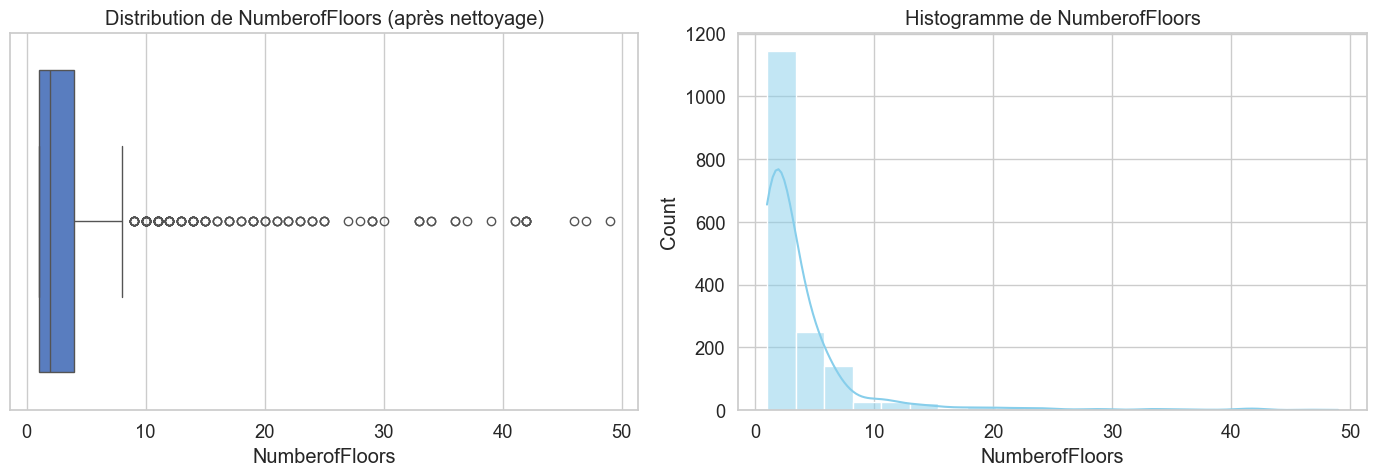

In [961]:
#  Visualisation avant/après
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="NumberofFloors", data=df, ax=axes[0])
axes[0].set_title("Distribution de NumberofFloors (après nettoyage)")

sns.histplot(df["NumberofFloors"], bins=20, kde=True, ax=axes[1], color="skyblue")
axes[1].set_title("Histogramme de NumberofFloors")

plt.tight_layout()
plt.show()


### Suppression lignes avec des valeurs par Défaut

Certaines lignes possèdent des valeurs artificielles, 
on peut le savoir grace a la colonne `DefaultData` qui donne True ou False

In [962]:
print("Nombre de lignes avant la suppression :", df.shape[0])
df = df.drop(df[df['DefaultData'] == True].index)
print("Nombre de lignes après la suppression :", df.shape[0])

Nombre de lignes avant la suppression : 1667
Nombre de lignes après la suppression : 1579


### Suppression lignes avec des valeurs "Non Compliant"

Dans la colonne `ComplianceStatus`, si on a `Non Compliant` cela signifie que ce bâtiment ne satisfait pas aux exigences de l'analyse de la consommation d'énergie

In [963]:
print("Nombre de lignes avant la suppression :", df.shape[0])
df = df.drop(df[df['ComplianceStatus'] == "Non-Compliant"].index)
print("Nombre de lignes après la suppression :", df.shape[0])

Nombre de lignes avant la suppression : 1579
Nombre de lignes après la suppression : 1561


In [964]:
data_na = df.isnull().mean() * 100
data_na[data_na>0].sort_values(ascending=True)

SiteEUIWN(kBtu/sf)                   0.064061
SiteEnergyUseWN(kBtu)                0.064061
LargestPropertyUseType               0.256246
LargestPropertyUseTypeGFA            0.256246
ZipCode                              0.832799
ENERGYSTARScore                     36.130685
SecondLargestPropertyUseType        46.060218
SecondLargestPropertyUseTypeGFA     46.060218
ThirdLargestPropertyUseType         77.706598
ThirdLargestPropertyUseTypeGFA      77.706598
YearsENERGYSTARCertified            93.721973
Comments                           100.000000
Outlier                            100.000000
dtype: float64

In [965]:
# suppressions des variables qui ne nous intéressent pas
print("Nombre de colonnes avant la suppression :", df.shape)

df.drop(['Comments','Outlier', 'YearsENERGYSTARCertified'
        ], axis=1, inplace=True)

print("Nombre de colonnes après la suppression :", df.shape)

Nombre de colonnes avant la suppression : (1561, 46)
Nombre de colonnes après la suppression : (1561, 43)


### Transformer YearBuilt en "Age"

YearBuilt n'a pas trop de sens si on ne sait pas quel age a le bâtiment, comme toutes ces valeurs ont été récupérés en 2016, on peut facilement transformer cette colonne en un age

In [966]:
# Calculer l'âge
df['Age'] = 2016 - df['YearBuilt']

In [967]:
# Réorganiser les colonnes pour placer "Age" avant "DataYear"
df = df[['Age'] + [col for col in df.columns if col != 'Age' and col != 'Bui']]

In [968]:
df = df[['OSEBuildingID'] + 
    [col for col in df.columns if col != 'OSEBuildingID']]

In [969]:
display(df)

,OSEBuildingID,Age,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,89,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,...,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,False,Compliant,249.98,2.83
1,2,20,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,...,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,False,Compliant,295.86,2.86
2,3,47,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,...,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,False,Compliant,2089.28,2.19
3,5,90,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,...,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,False,Compliant,286.43,4.67
4,8,36,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,...,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,False,Compliant,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3370,50221,34,2016,Nonresidential COS,Other,High Point Community Center,6920 34th Ave SW,Seattle,WA,NaN,...,1.025432e+06,0.00,1.853347e+05,6.323620e+05,2997.199951,2.997200e+05,False,Compliant,20.33,1.11
3372,50223,12,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,...,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,False,Compliant,32.17,2.01
3373,50224,42,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,...,6.053764e+06,0.00,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,False,Compliant,223.54,16.99
3374,50225,27,2016,Nonresidential COS,Mixed Use Property,South Park Community Center,8319 8th Ave S,Seattle,WA,NaN,...,7.828413e+05,0.00,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,False,Compliant,22.11,1.57


In [970]:
# suppressions des variables qui ne nous intéressent pas
print("Nombre de colonnes avant la suppression :", df.shape)

df.drop(['OSEBuildingID', 'PropertyName','Address','State','ZipCode','City', 'TaxParcelIdentificationNumber','Neighborhood', 'CouncilDistrictCode'
        ], axis=1, inplace=True)

print("Nombre de colonnes après la suppression :", df.shape)

Nombre de colonnes avant la suppression : (1561, 44)
Nombre de colonnes après la suppression : (1561, 35)


In [971]:
df.columns.tolist()

['Age',
 'DataYear',
 'BuildingType',
 'PrimaryPropertyType',
 'Latitude',
 'Longitude',
 'YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'ENERGYSTARScore',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'DefaultData',
 'ComplianceStatus',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity']

Nous avons différentes unités répertoriées :

**kWh**: kilowattheure

**Therm** : correspond approximativement à l'énergie libérée par la combustion de 2 kg (approx. 3 l) d'essence.

**kBtu** : British thermal unit Nous choississons de travailler avec le kBtu.

Le suffixe WN identifie les valeurs normalisées selon la météo. C'est la consommation d'énergie du site que la propriété aurait consommée dans des conditions météorologiques moyennes sur 30 ans. C'est donc déjà une prédiction.

In [972]:
# suppressions des variables qui ne nous intéressent pas
print("Nombre de colonnes avant la suppression :", df.shape)

df.drop(['Electricity(kWh)', 'NaturalGas(therms)',
                   'SourceEUIWN(kBtu/sf)','SiteEUIWN(kBtu/sf)',
                   'SiteEnergyUseWN(kBtu)', 'GHGEmissionsIntensity'
        ], axis=1, inplace=True)

print("Nombre de colonnes après la suppression :", df.shape)

Nombre de colonnes avant la suppression : (1561, 35)
Nombre de colonnes après la suppression : (1561, 29)


In [973]:
nan_counts = df.isna().sum()
nan_counts

Age                                   0
DataYear                              0
BuildingType                          0
PrimaryPropertyType                   0
Latitude                              0
Longitude                             0
YearBuilt                             0
NumberofBuildings                     0
NumberofFloors                        0
PropertyGFATotal                      0
PropertyGFAParking                    0
PropertyGFABuilding(s)                0
ListOfAllPropertyUseTypes             0
LargestPropertyUseType                4
LargestPropertyUseTypeGFA             4
SecondLargestPropertyUseType        719
SecondLargestPropertyUseTypeGFA     719
ThirdLargestPropertyUseType        1213
ThirdLargestPropertyUseTypeGFA     1213
ENERGYSTARScore                     564
SiteEUI(kBtu/sf)                      0
SourceEUI(kBtu/sf)                    0
SiteEnergyUse(kBtu)                   0
SteamUse(kBtu)                        0
Electricity(kBtu)                     0


`LargestPropertyUseType` et `LargestPropertyUseTypeGFA` ne doivent pas posséder de NaN

In [974]:
print("Nombre de lignes avant la suppression :", df.shape[0])
df.dropna(subset=['LargestPropertyUseType', 'LargestPropertyUseTypeGFA'], inplace=True)
print("Nombre de lignes après la suppression :", df.shape[0])

Nombre de lignes avant la suppression : 1561
Nombre de lignes après la suppression : 1557


### Supression lignes Type =! NaN MAIS TypeGFA = 0 ou NaN 
**SecondLargestPropertyUseType**

On vérifie si on a pas des cas ou `SecondLargestPropertyUseType` =! NaN mais que `SecondLargestPropertyUseTypeGFA` = 0 ou NaN

In [975]:
# Nombre de lignes avant suppression
print("Nombre de lignes avant :", df.shape[0])

# Supprimer les lignes incohérentes :
# type existe (non NaN) mais GFA est manquant ou nul
df = df.drop(df[
    (df['SecondLargestPropertyUseType'].notna()) & 
    ((df['SecondLargestPropertyUseTypeGFA'].isna()) | (df['SecondLargestPropertyUseTypeGFA'] == 0))
].index)

# Nombre de lignes après suppression
print("Nombre de lignes après :", df.shape[0])

Nombre de lignes avant : 1557
Nombre de lignes après : 1481


**ThirdLargestPropertyUseType**

In [976]:
# Nombre de lignes avant suppression
print("Nombre de lignes avant :", df.shape[0])

# Supprimer les lignes incohérentes :
# type existe (non NaN) mais GFA est manquant ou nul
df = df.drop(df[
    (df['ThirdLargestPropertyUseType'].notna()) & 
    ((df['ThirdLargestPropertyUseTypeGFA'].isna()) | (df['ThirdLargestPropertyUseTypeGFA'] == 0))
].index)

# Nombre de lignes après suppression
print("Nombre de lignes après :", df.shape[0])

Nombre de lignes avant : 1481
Nombre de lignes après : 1459


### Transformation des NaN en 0

In [977]:
# Comptez les valeurs manquantes pour chaque colonne
nb_nan_par_colonne = df.isna().sum()

print(nb_nan_par_colonne)

Age                                   0
DataYear                              0
BuildingType                          0
PrimaryPropertyType                   0
Latitude                              0
Longitude                             0
YearBuilt                             0
NumberofBuildings                     0
NumberofFloors                        0
PropertyGFATotal                      0
PropertyGFAParking                    0
PropertyGFABuilding(s)                0
ListOfAllPropertyUseTypes             0
LargestPropertyUseType                0
LargestPropertyUseTypeGFA             0
SecondLargestPropertyUseType        715
SecondLargestPropertyUseTypeGFA     715
ThirdLargestPropertyUseType        1135
ThirdLargestPropertyUseTypeGFA     1135
ENERGYSTARScore                     533
SiteEUI(kBtu/sf)                      0
SourceEUI(kBtu/sf)                    0
SiteEnergyUse(kBtu)                   0
SteamUse(kBtu)                        0
Electricity(kBtu)                     0


In [978]:
df['SecondLargestPropertyUseTypeGFA'] = df['SecondLargestPropertyUseTypeGFA'].fillna(0)
df['ThirdLargestPropertyUseTypeGFA'] = df['ThirdLargestPropertyUseTypeGFA'].fillna(0)

In [979]:
df.head()

,Age,DataYear,BuildingType,PrimaryPropertyType,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,...,ENERGYSTARScore,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
0,89,2016,NonResidential,Hotel,47.61220,-122.33799,1927,1.0,12,88434,...,60.0,81.699997,182.500000,7226362.5,2003882.00,3946027.0,1276453.0,False,Compliant,249.98
1,20,2016,NonResidential,Hotel,47.61317,-122.33393,1996,1.0,11,103566,...,61.0,94.800003,176.100006,8387933.0,0.00,3242851.0,5145082.0,False,Compliant,295.86
2,47,2016,NonResidential,Hotel,47.61393,-122.33810,1969,1.0,41,956110,...,43.0,96.000000,241.899994,72587024.0,21566554.00,49526664.0,1493800.0,False,Compliant,2089.28
3,90,2016,NonResidential,Hotel,47.61412,-122.33664,1926,1.0,10,61320,...,56.0,110.800003,216.199997,6794584.0,2214446.25,2768924.0,1811213.0,False,Compliant,286.43
5,17,2016,Nonresidential COS,Other,47.61623,-122.33657,1999,1.0,2,97288,...,NaN,136.100006,316.299988,12086616.0,0.00,7371434.0,4715182.0,False,Compliant,301.81


### Supression des lignes (Parking)

On supprime les lignes où il existe une surface de parking (`PropertyGFAParking > 0`) mais où aucune colonne d’usage ne mentionne “Parking”, et où les surfaces d’usage associées sont nulles.

In [980]:
df_filtered = df[df['PropertyGFAParking'] > 0]
df_filtered = df_filtered[
    (df_filtered["LargestPropertyUseType"] != "Parking") &
    (df_filtered["SecondLargestPropertyUseType"] != "Parking") &
    (df_filtered["ThirdLargestPropertyUseType"] != "Parking") &
    (df_filtered["SecondLargestPropertyUseTypeGFA"] == 0) &
    (df_filtered["ThirdLargestPropertyUseTypeGFA"] == 0)
]

In [981]:
df_filtered_head = df_filtered.loc[:, ['PropertyGFAParking', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 
                                       'SecondLargestPropertyUseType' , 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA']]
df_filtered_head.head()

,PropertyGFAParking,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA
2,196718,Hotel,756493.0,NaN,0.0,NaN,0.0
5,37198,Police Station,88830.0,NaN,0.0,NaN,0.0
10,19279,Hotel,133884.0,NaN,0.0,NaN,0.0
11,61161,Hotel,336640.0,NaN,0.0,NaN,0.0
27,38281,Hotel,128909.0,NaN,0.0,NaN,0.0


In [982]:
print("Nombre de lignes avant la suppression :", df.shape[0])
df = df.drop(df_filtered.index)
print("Nombre de lignes après la suppression :", df.shape[0])

Nombre de lignes avant la suppression : 1459
Nombre de lignes après la suppression : 1395


In [983]:
def statistiques_descriptives(df):
    """ Statistiques descriptives des variables structurelles/énergie principales"""
    cols = [
        "Age", "SiteEUI(kBtu/sf)", "PropertyGFATotal",
        "SiteEnergyUse(kBtu)", "TotalGHGEmissions"    
    ]
    cols = [c for c in cols if c in df.columns]
    return df[cols].describe(include="all")

In [984]:
stats = statistiques_descriptives(df)
display(stats)


,Age,SiteEUI(kBtu/sf),PropertyGFATotal,SiteEnergyUse(kBtu),TotalGHGEmissions
count,1395.000000,1395.000000,1.395000e+03,1.395000e+03,1395.000000
mean,55.895341,71.621147,1.148749e+05,8.128799e+06,180.555835
std,33.020044,73.377149,1.989572e+05,2.303508e+07,753.096581
min,1.000000,0.000000,1.128500e+04,0.000000e+00,-0.800000
25%,28.000000,33.650000,2.864800e+04,1.169672e+06,19.470000
50%,53.000000,52.500000,4.723700e+04,2.485521e+06,48.990000
75%,87.500000,81.350002,1.045690e+05,6.784752e+06,133.105000
max,116.000000,834.400024,2.200000e+06,4.483853e+08,16870.980000


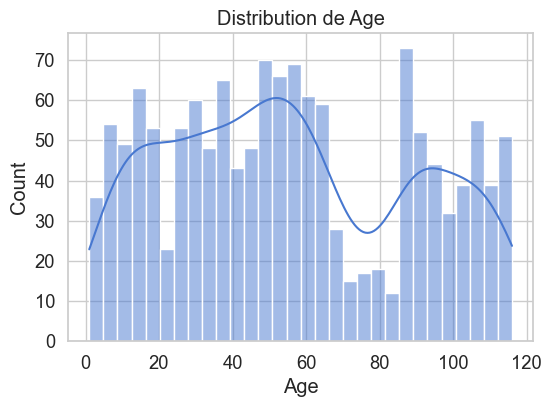

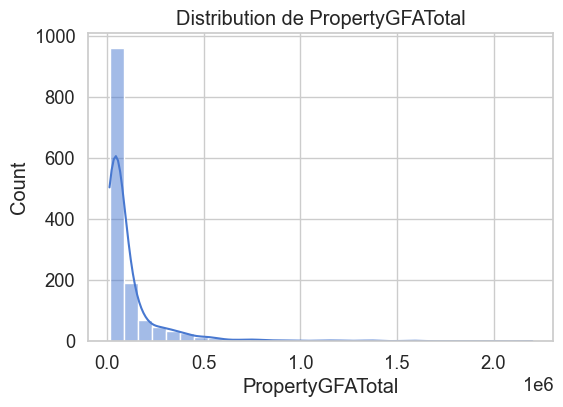

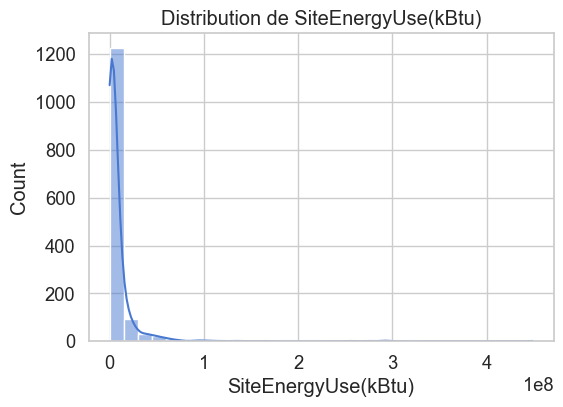

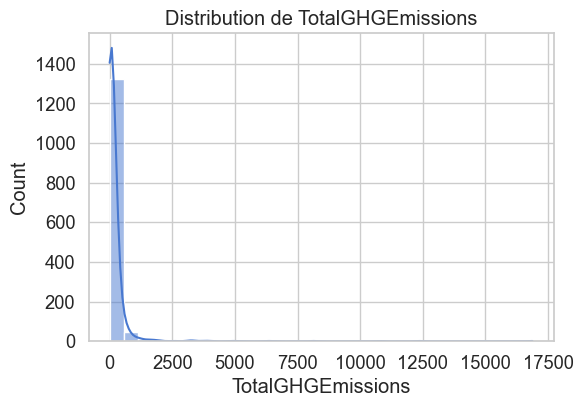

In [985]:
for col in ["Age", "PropertyGFATotal", "SiteEnergyUse(kBtu)", "TotalGHGEmissions"]:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution de {col}")
    plt.show()


Les variables `PropertyGFATotal", "SiteEnergyUse(kBtu)", "TotalGHGEmissions"`:sont asymétriques donc la transformation log est nécessaire

### Vérification des valeurs négatives

In [986]:
df.min(numeric_only=True)

Age                                        1
DataYear                                2016
Latitude                            47.50959
Longitude                         -122.41182
YearBuilt                               1900
NumberofBuildings                        1.0
NumberofFloors                             1
PropertyGFATotal                       11285
PropertyGFAParking                         0
PropertyGFABuilding(s)                 10925
LargestPropertyUseTypeGFA             5656.0
SecondLargestPropertyUseTypeGFA          0.0
ThirdLargestPropertyUseTypeGFA           0.0
ENERGYSTARScore                          1.0
SiteEUI(kBtu/sf)                         0.0
SourceEUI(kBtu/sf)                       0.0
SiteEnergyUse(kBtu)                      0.0
SteamUse(kBtu)                           0.0
Electricity(kBtu)                  -115417.0
NaturalGas(kBtu)                         0.0
DefaultData                            False
TotalGHGEmissions                       -0.8
dtype: obj

Supprime toutes les lignes où la consommation ou les émissions sont négatives. 

Il y a des valeurs  anormales ou non physiques

In [987]:
def clean_energy_data(df):
    """
    Supprime toutes les lignes anormales ou incohérentes du DataFrame énergétique.
    """
    df = df.copy()
    print("Nombre de lignes avant nettoyage :", df.shape[0])

    # Supprimer les valeurs négatives 
    cols_negative = ['Electricity(kBtu)', 'TotalGHGEmissions']
    for col in cols_negative:
        if col in df.columns:
            df = df[df[col] >= 0]

    # Supprimer les valeurs nulles non physiques 
    cols_zero_invalid = [
        'PropertyGFATotal', 'SiteEnergyUse(kBtu)',
        'SiteEUI(kBtu/sf)', 'TotalGHGEmissions'
    ]
    for col in cols_zero_invalid:
        if col in df.columns:
            df = df[df[col] > 0]

    # Supprimer les bâtiments sans structure
    if 'NumberofBuildings' in df.columns:
        df = df[df['NumberofBuildings'] > 0]
    if 'NumberofFloors' in df.columns:
        df = df[df['NumberofFloors'] > 0]

    print("Nombre de lignes après nettoyage :", df.shape[0])
    return df

In [988]:
df = clean_energy_data(df)

Nombre de lignes avant nettoyage : 1395
Nombre de lignes après nettoyage : 1379


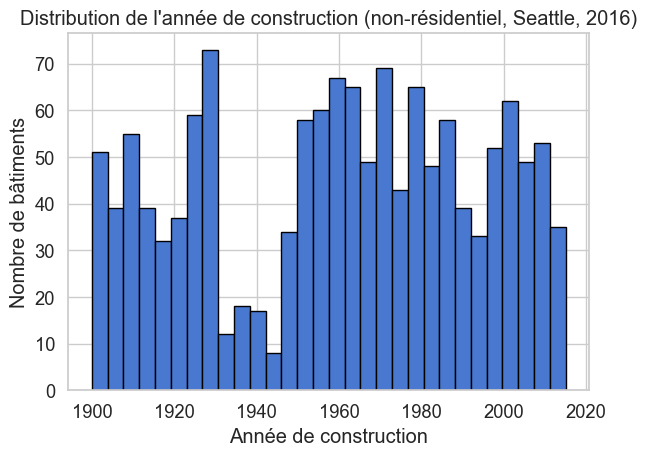

In [989]:
 # Histogramme de l'année de construction
plt.figure()
df["YearBuilt"].dropna().astype(int).plot(kind="hist", bins=30, edgecolor="black")
plt.title("Distribution de l'année de construction (non-résidentiel, Seattle, 2016)")
plt.xlabel("Année de construction")
plt.ylabel("Nombre de bâtiments")
plt.tight_layout()

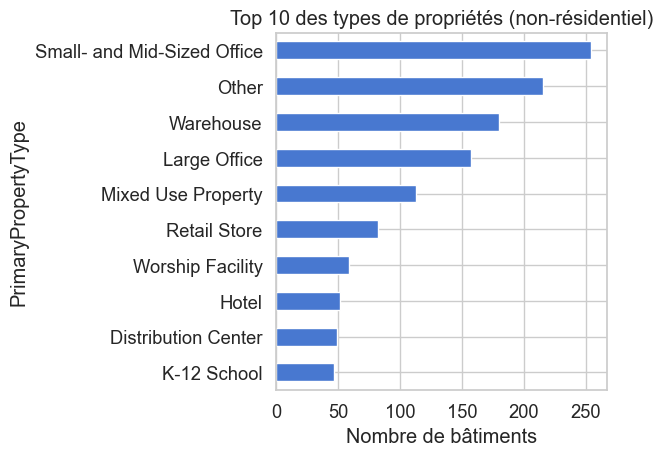

In [990]:
# Barres : top 10 des types de propriétés
plt.figure()
top10 = df["PrimaryPropertyType"].value_counts().head(10).sort_values(ascending=True)
top10.plot(kind="barh")
plt.title("Top 10 des types de propriétés (non-résidentiel)")
plt.xlabel("Nombre de bâtiments")
plt.tight_layout()

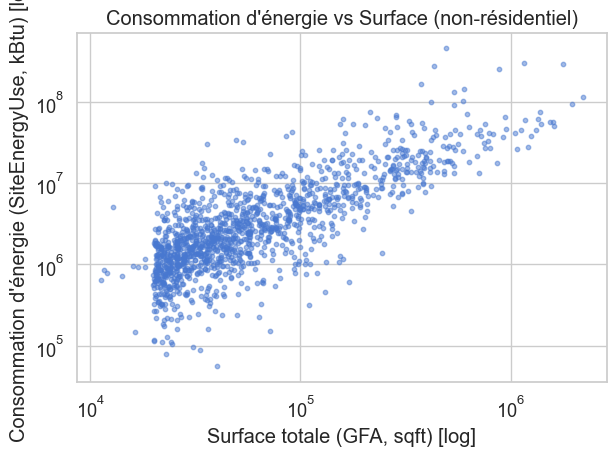

In [991]:
# Nuage : énergie vs surface
plt.figure()
plt.scatter(df["PropertyGFATotal"], df["SiteEnergyUse(kBtu)"], alpha=0.5, s=10)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Surface totale (GFA, sqft) [log]")
plt.ylabel("Consommation d'énergie (SiteEnergyUse, kBtu) [log]")
plt.title("Consommation d'énergie vs Surface (non-résidentiel)")
plt.tight_layout()

/var/folders/6w/kyt603rj6b11yw5nslgnnr8c0000gn/T/ipykernel_80209/3749297918.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=top10, showfliers=False)


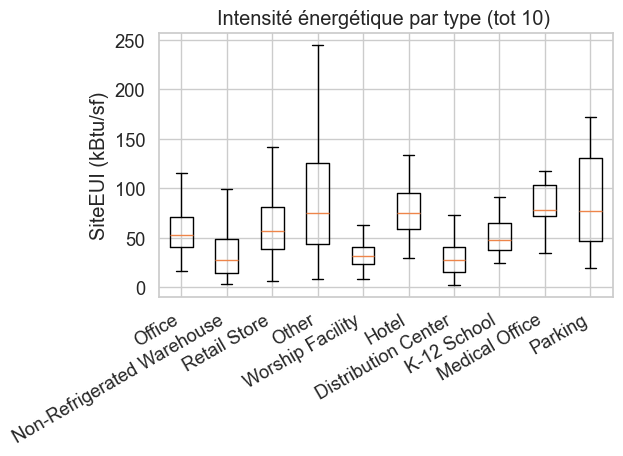

In [992]:
 # Boxplots : SiteEUI par type (top 10)
plt.figure()
top10 = df["LargestPropertyUseType"].value_counts().head(10).index.tolist()
data_for_box = [df.loc[df["LargestPropertyUseType"].eq(t), "SiteEUI(kBtu/sf)"].dropna() for t in top10]
plt.boxplot(data_for_box, labels=top10, showfliers=False)
plt.xticks(rotation=30, ha="right")
plt.ylabel("SiteEUI (kBtu/sf)")
plt.title("Intensité énergétique par type (tot 10) ")
plt.tight_layout()

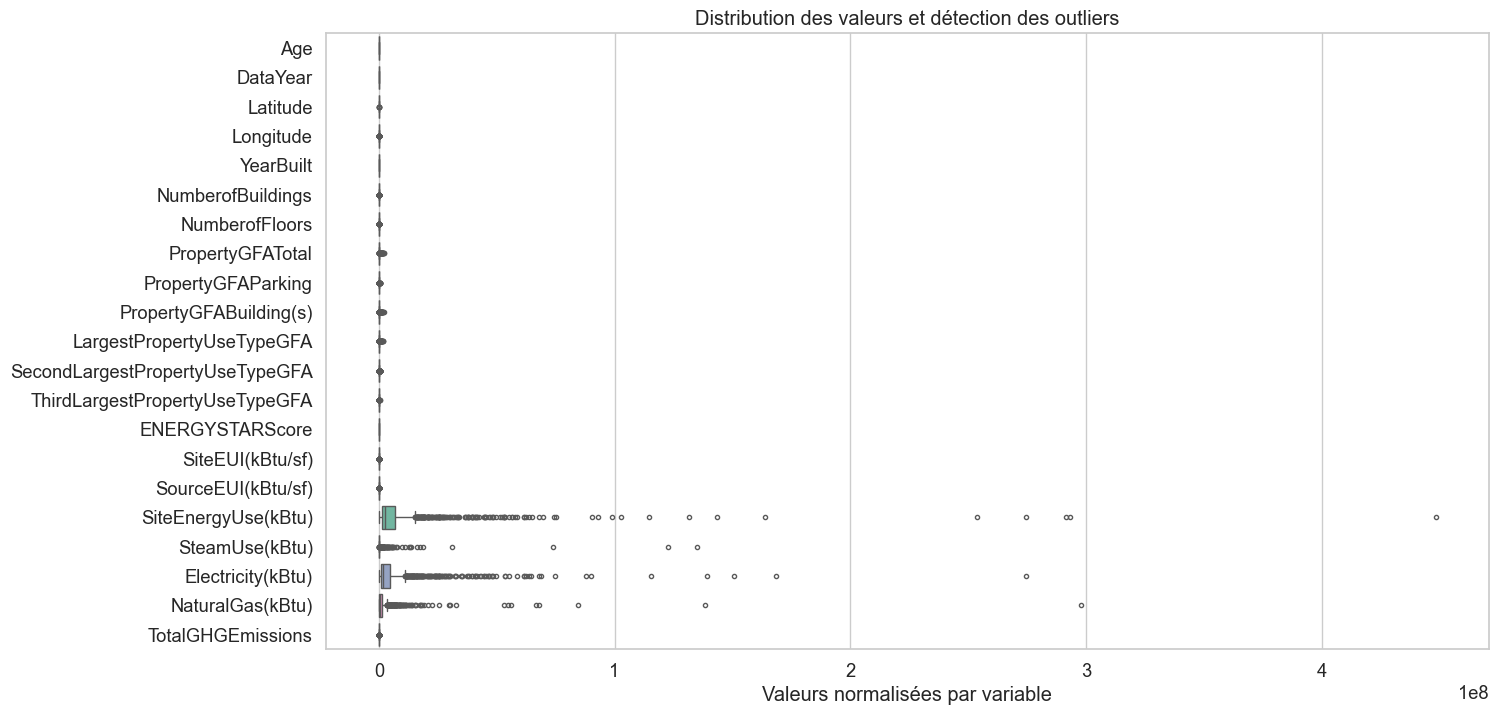

In [993]:
# Sélection des colonnes numériques
num_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[num_cols], orient="h", palette="Set2", fliersize=3)
plt.title("Distribution des valeurs et détection des outliers")
plt.xlabel("Valeurs normalisées par variable")
plt.show()

Ces valeurs “extrêmes” sont réelles et reflètent des usages particuliers (bâtiments plus grands comme les hôpitaux, universités, campus géants..) Pour limiter leur effet sans les enlever complètement on va caper les valeurs les plus hautes

In [994]:
df.sort_values('SiteEnergyUse(kBtu)', ascending=False).head(10)


,Age,DataYear,BuildingType,PrimaryPropertyType,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,...,ENERGYSTARScore,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
35,24,2016,Campus,Mixed Use Property,47.534930,-122.317880,1992,1.0,3,494835,...,8.0,221.699997,388.200012,448385312.0,0.0,150476283.0,297909000.0,False,Compliant,16870.98
170,16,2016,NonResidential,Hospital,47.603990,-122.323770,2000,9.0,8,1158691,...,29.0,217.100006,502.899994,293090784.0,122575032.0,168683602.0,1832129.0,False,Compliant,10734.57
618,22,2016,NonResidential,Hospital,47.608951,-122.322402,1994,7.0,14,1765970,...,54.0,177.899994,377.000000,291614432.0,134943456.0,139354828.0,17316120.0,False,Compliant,12307.16
558,35,2016,NonResidential,Other,47.614380,-122.338710,1981,1.0,33,429405,...,98.0,639.700012,2007.900024,274682208.0,0.0,274532495.0,149672.0,False,Compliant,1921.82
124,63,2016,NonResidential,Hospital,47.662310,-122.281460,1953,6.0,10,879000,...,10.0,288.799988,578.200012,253832464.0,0.0,115641210.0,138191238.0,False,Compliant,8145.52
3264,96,2016,NonResidential,Hospital,47.609860,-122.327740,1920,1.0,8,374466,...,74.0,162.300003,367.899994,163945984.0,73885472.0,90060497.0,0.0,False,Compliant,6330.91
167,26,2016,NonResidential,Hospital,47.607050,-122.309660,1990,6.0,5,597519,...,34.0,238.399994,454.399994,143423024.0,0.0,58754927.0,84668094.0,False,Compliant,4906.33
340,19,2016,Campus,Other,47.628550,-122.330350,1997,1.0,5,535947,...,NaN,245.100006,509.399994,131373880.0,0.0,64627449.0,66746425.0,False,Compliant,3995.45
1494,77,2016,Campus,University,47.610650,-122.317110,1939,1.0,2,2200000,...,NaN,66.699997,145.000000,114648520.0,0.0,61672821.0,52975694.0,False,Compliant,3243.48
1690,52,2016,NonResidential,Medical Office,47.620140,-122.312280,1964,1.0,3,591981,...,60.0,173.399994,351.600006,102673696.0,0.0,48002292.0,54671394.0,False,Compliant,3238.24


Un bâtiment de type campus est très supérieur aux autres données. Il ne s'agit sans doute pas d'une valeur abérrante mais d'une valeur atypique qui est très isolée. Nous allons ici la supprimer de nos données sources.

In [995]:
df[df['SiteEnergyUse(kBtu)'] >= 448385312.0]

,Age,DataYear,BuildingType,PrimaryPropertyType,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,...,ENERGYSTARScore,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions
35,24,2016,Campus,Mixed Use Property,47.53493,-122.31788,1992,1.0,3,494835,...,8.0,221.699997,388.200012,448385312.0,0.0,150476283.0,297909000.0,False,Compliant,16870.98


In [996]:
df = df[df['SiteEnergyUse(kBtu)'] < 448385312.0]

In [997]:
print("Nombre de lignes après suppression :", len(df))


Nombre de lignes après suppression : 1378


### Normalisation des variables d’usage du bâtiment

In [998]:
df.SecondLargestPropertyUseType.sort_values(ascending=True).unique()

array(['Adult Education', 'Automobile Dealership', 'Bank Branch',
       'Bar/Nightclub', 'College/University',
       'Convenience Store without Gas Station', 'Courthouse',
       'Data Center', 'Distribution Center', 'Enclosed Mall',
       'Financial Office', 'Fitness Center/Health Club/Gym', 'Food Sales',
       'Food Service', 'Hospital (General Medical & Surgical)', 'Hotel',
       'K-12 School', 'Laboratory', 'Manufacturing/Industrial Plant',
       'Medical Office', 'Movie Theater', 'Multifamily Housing',
       'Non-Refrigerated Warehouse', 'Office', 'Other',
       'Other - Education', 'Other - Entertainment/Public Assembly',
       'Other - Lodging/Residential', 'Other - Public Services',
       'Other - Recreation', 'Other - Restaurant/Bar', 'Other - Services',
       'Parking', 'Performing Arts',
       'Personal Services (Health/Beauty, Dry Cleaning, etc)',
       'Pre-school/Daycare', 'Refrigerated Warehouse',
       'Repair Services (Vehicle, Shoe, Locksmith, etc)',
   

In [999]:
df.ThirdLargestPropertyUseType.sort_values(ascending=True).unique()

array(['Bank Branch', 'Bar/Nightclub',
       'Convenience Store without Gas Station', 'Data Center',
       'Distribution Center', 'Fast Food Restaurant', 'Financial Office',
       'Fitness Center/Health Club/Gym', 'Food Service', 'Hotel',
       'K-12 School', 'Laboratory', 'Manufacturing/Industrial Plant',
       'Medical Office', 'Multifamily Housing',
       'Non-Refrigerated Warehouse', 'Office', 'Other',
       'Other - Education', 'Other - Entertainment/Public Assembly',
       'Other - Recreation', 'Other - Restaurant/Bar', 'Other - Services',
       'Other - Technology/Science', 'Other - Utility',
       'Other/Specialty Hospital', 'Parking',
       'Personal Services (Health/Beauty, Dry Cleaning, etc)',
       'Pre-school/Daycare', 'Refrigerated Warehouse', 'Restaurant',
       'Retail Store', 'Self-Storage Facility', 'Social/Meeting Hall',
       'Strip Mall', 'Supermarket/Grocery Store', 'Vocational School',
       'Worship Facility', nan], dtype=object)

In [1000]:
df.PrimaryPropertyType.sort_values(ascending=True).unique()

array(['Distribution Center', 'Hospital', 'Hotel', 'K-12 School',
       'Laboratory', 'Large Office', 'Low-Rise Multifamily',
       'Medical Office', 'Mixed Use Property', 'Other',
       'Refrigerated Warehouse', 'Residence Hall', 'Restaurant',
       'Retail Store', 'Self-Storage Facility', 'Senior Care Community',
       'Small- and Mid-Sized Office', 'Supermarket / Grocery Store',
       'University', 'Warehouse', 'Worship Facility'], dtype=object)

In [1001]:
# Normalisation des types de propriété
def normalize_property_type(value):
    """Nettoie et uniformise les types de propriété en catégories cohérentes."""
    if pd.isna(value):
        return "no use"
    
    v = value.strip().lower()
    
    # Normalisation par groupe de similarité
    mapping = {
        "hospital": ["hospital", "general medical & surgical", "medical office", "healthcare", "clinic"],
        "office": ["office", "large office", "small- and mid-sized office", "financial office"],
        "school": ["k-12 school", "elementary school", "middle school", "high school", "vocational school", "pre-school/daycare"],
        "university": ["college/university", "campus"],
        "retail": ["retail store", "strip mall", "shopping mall", "supermarket / grocery store", "supermarket/grocery store"],
        "warehouse": ["warehouse", "distribution center", "non-refrigerated warehouse", "refrigerated warehouse"],
        "residential": ["multifamily housing", "residence hall/dormitory", "low-rise multifamily", "senior care community", "hotel", "lodging/residential"],
        "restaurant": ["restaurant", "food service", "fast food restaurant", "bar/nightclub", "other - restaurant/bar"],
        "industrial": ["manufacturing/industrial plant", "data center", "laboratory", "other - technology/science"],
        "public": ["courthouse", "public services", "worship facility", "social/meeting hall", "performing arts", "community center"],
        "parking": ["parking", "garage"],
        "other": ["other", "unknown", "miscellaneous", "self-storage facility"]
    }

    for category, keywords in mapping.items():
        if any(k in v for k in keywords):
            return category.capitalize()
    return "Other"

In [1002]:
# Application à plusieurs colonnes
for col in ['PrimaryPropertyType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType','LargestPropertyUseType']:
    df[col] = df[col].apply(normalize_property_type)

In [1003]:
# Vérification du résultat
for col in ['PrimaryPropertyType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'LargestPropertyUseType']:
    print(f"\n{col} — catégories uniques normalisées :")
    print(sorted(df[col].unique()))



PrimaryPropertyType — catégories uniques normalisées :
['Hospital', 'Industrial', 'Office', 'Other', 'Public', 'Residential', 'Restaurant', 'Retail', 'School', 'Warehouse']

SecondLargestPropertyUseType — catégories uniques normalisées :
['Hospital', 'Industrial', 'Office', 'Other', 'Parking', 'Public', 'Residential', 'Restaurant', 'Retail', 'School', 'University', 'Warehouse', 'no use']

ThirdLargestPropertyUseType — catégories uniques normalisées :
['Hospital', 'Industrial', 'Office', 'Other', 'Parking', 'Public', 'Residential', 'Restaurant', 'Retail', 'School', 'Warehouse', 'no use']

LargestPropertyUseType — catégories uniques normalisées :
['Hospital', 'Industrial', 'Office', 'Other', 'Parking', 'Public', 'Residential', 'Restaurant', 'Retail', 'School', 'University', 'Warehouse']


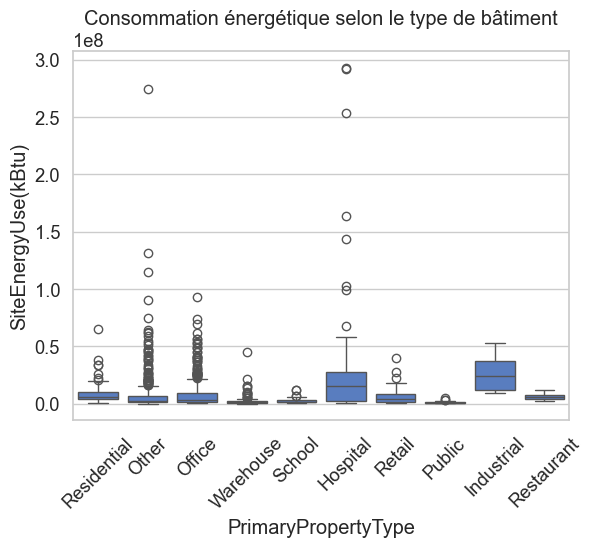

In [1004]:
sns.boxplot(x="PrimaryPropertyType", y="SiteEnergyUse(kBtu)", data=df)
plt.xticks(rotation=45)
plt.title("Consommation énergétique selon le type de bâtiment")
plt.show()


Regardons la consommation moyenne par type de bâtiment. 

Ca nous donne les types de bâtiments les plus énergivores.

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

In [1005]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1378.0,5.615893e+01,3.306043e+01,1.00000,2.900000e+01,5.300000e+01,8.800000e+01,1.160000e+02
DataYear,1378.0,2.016000e+03,0.000000e+00,2016.00000,2.016000e+03,2.016000e+03,2.016000e+03,2.016000e+03
Latitude,1378.0,4.761479e+01,4.609952e-02,47.50959,4.758674e+01,4.761185e+01,4.764448e+01,4.773387e+01
Longitude,1378.0,-1.223336e+02,2.310147e-02,-122.41182,-1.223427e+02,-1.223333e+02,-1.223229e+02,-1.222618e+02
YearBuilt,1378.0,1.959841e+03,3.306043e+01,1900.00000,1.928000e+03,1.963000e+03,1.987000e+03,2.015000e+03
NumberofBuildings,1378.0,1.132075e+00,1.183266e+00,1.00000,1.000000e+00,1.000000e+00,1.000000e+00,2.700000e+01
NumberofFloors,1378.0,4.080552e+00,5.620410e+00,1.00000,1.000000e+00,2.000000e+00,4.000000e+00,4.900000e+01
PropertyGFATotal,1378.0,1.150738e+05,1.998306e+05,11285.00000,2.850775e+04,4.664500e+04,1.042640e+05,2.200000e+06
PropertyGFAParking,1378.0,1.260769e+04,4.305766e+04,0.00000,0.000000e+00,0.000000e+00,0.000000e+00,5.126080e+05
PropertyGFABuilding(s),1378.0,1.024661e+05,1.786860e+05,10925.00000,2.773350e+04,4.521300e+04,9.430050e+04,2.200000e+06


In [1006]:
df.columns.tolist()

['Age',
 'DataYear',
 'BuildingType',
 'PrimaryPropertyType',
 'Latitude',
 'Longitude',
 'YearBuilt',
 'NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'ENERGYSTARScore',
 'SiteEUI(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kBtu)',
 'NaturalGas(kBtu)',
 'DefaultData',
 'ComplianceStatus',
 'TotalGHGEmissions']

In [1007]:
# suppressions des variables qui ne nous intéressent pas
print("Nombre de colonnes avant la suppression :", df.shape)

df.drop(['ENERGYSTARScore', 'DefaultData', 'ComplianceStatus', 'DataYear'
        ], axis=1, inplace=True, errors='ignore')

print("Nombre de colonnes après la suppression :", df.shape)

Nombre de colonnes avant la suppression : (1378, 29)
Nombre de colonnes après la suppression : (1378, 25)


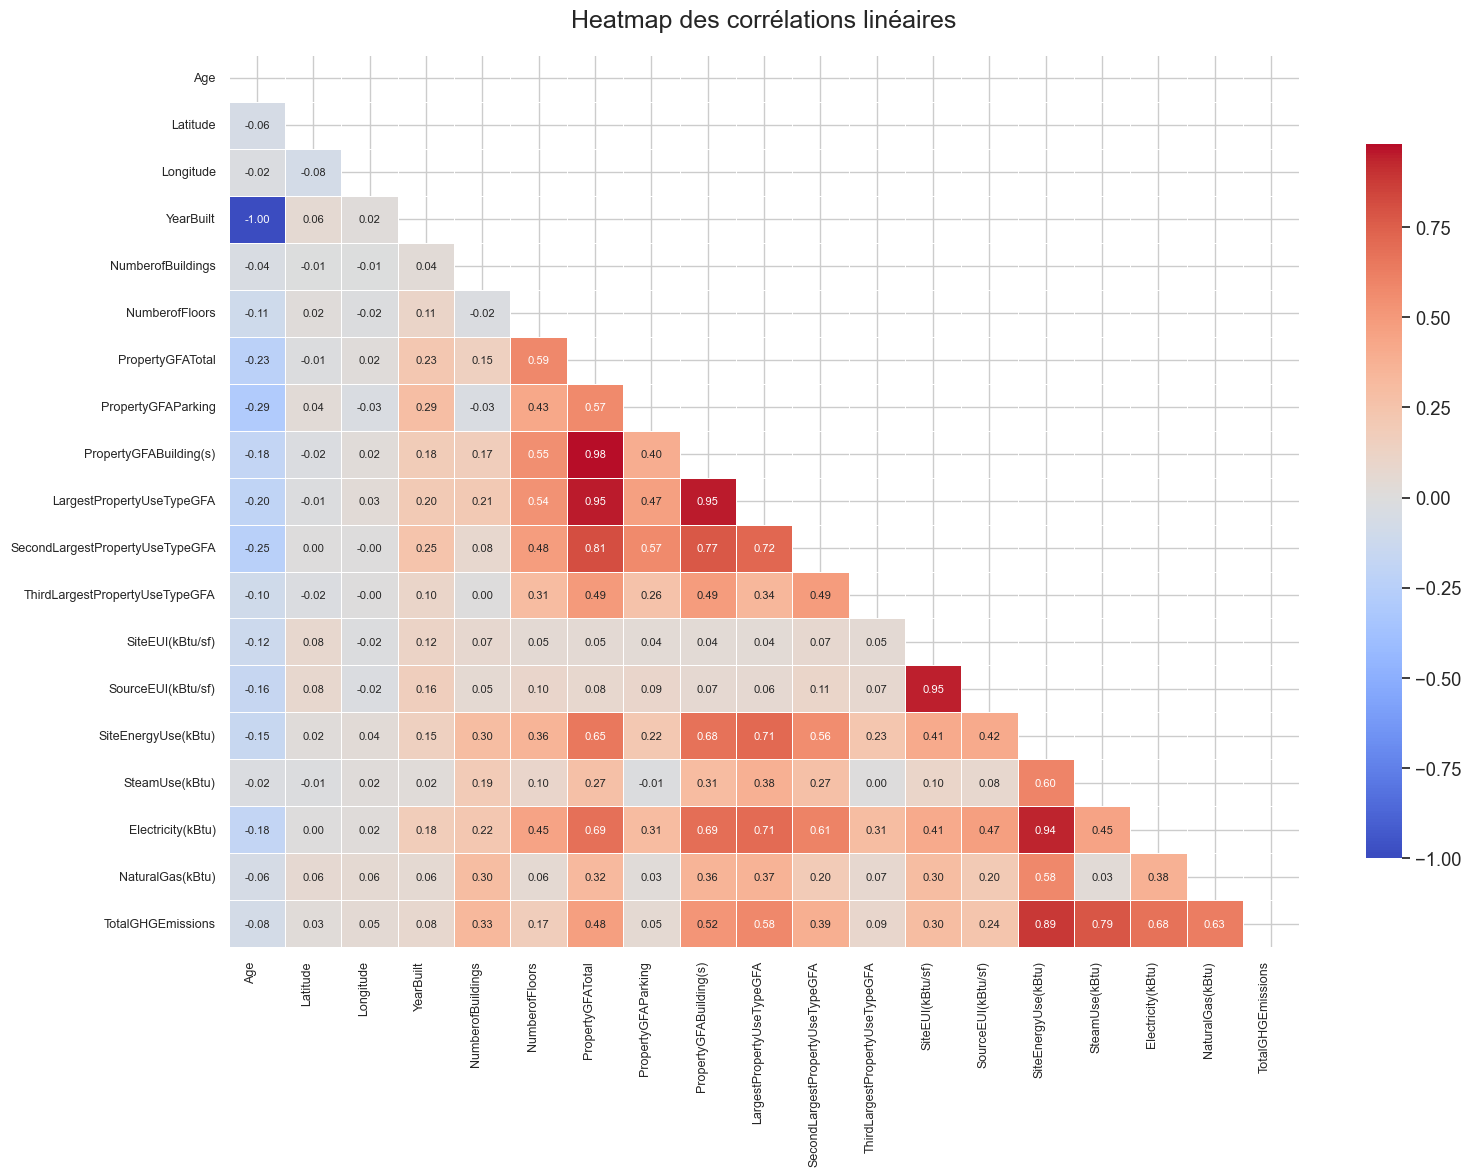

In [1008]:
# Sélection uniquement des colonnes numériques
df_num = df.select_dtypes(include=['number'])

# Calcul de la matrice de corrélation
corr = df_num.corr(method="pearson")

# Masque pour ne pas afficher les doublons
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

# Affichage de la heatmap
plt.figure(figsize=(16, 12))
sns.heatmap( corr,
    mask=mask,
    annot=True,         
    fmt=".2f",          
    cmap="coolwarm",    
    center=0,
    linewidths=0.5,    
    cbar_kws={"shrink": 0.8},  
    annot_kws={"size": 8}      
)
plt.title("Heatmap des corrélations linéaires", fontsize=18, pad=20)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

Pour les varaibles à prédire `TotalGHGEmissions et SiteEnergyUse(kBtu)`, on remarque des corrélations linéaires quasi similaires avec les variables de relevés (les consommations) mais également avec le nombre de batiments ou d'étages ains que les surfaces au sol

In [1009]:
threshold = 0.7
corr_pairs = corr.unstack().sort_values(kind="quicksort")
strong_corr = (pd.DataFrame(corr_pairs[(abs(corr_pairs) > threshold)])
               .reset_index().rename(columns={0:'corr_coeff'}))
strong_corr = strong_corr[(strong_corr.index%2 == 0) & (strong_corr['level_0'] != strong_corr['level_1'])]
strong_corr.sort_values('corr_coeff', ascending=False)

,level_0,level_1,corr_coeff
24,PropertyGFABuilding(s),PropertyGFATotal,0.980300
22,PropertyGFATotal,LargestPropertyUseTypeGFA,0.951846
20,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,0.951762
18,SourceEUI(kBtu/sf),SiteEUI(kBtu/sf),0.947960
16,SiteEnergyUse(kBtu),Electricity(kBtu),0.936298
14,SiteEnergyUse(kBtu),TotalGHGEmissions,0.885306
12,PropertyGFATotal,SecondLargestPropertyUseTypeGFA,0.813872
10,SteamUse(kBtu),TotalGHGEmissions,0.786858
8,SecondLargestPropertyUseTypeGFA,PropertyGFABuilding(s),0.772007
6,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,0.724068


Nous allons donc créer de nouvelles variables pour tenter de gommer ces corrélations linéaires grace au ration de surfaces

### Création Colonnes binaires d'usage

Pour `SteamUse(kBtu), Electricity(kBtu) et NaturalGas(therms)`, il vaut mieux rajouter des colonnes binaires qui indiquent si oui ou non on utilise du Steam, Electrecity, Gas...

De plus, garder `SteamUse(kBtu), Electricity(kBtu) et NaturalGas(therms)` causerait un probleme de data-leakage car ces données sont directement corrélés à nos targets

In [1010]:
# Fonction conditionnelle pour créer les nouvelles colonnes
def create_usage_column(value):
    """Retourne 1 si le bâtiment consomme cette énergie, sinon 0"""
    return 1 if value > 0 else 0

for energy_col in ['SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)']:
    usage_col = energy_col.replace('(kBtu)', '(kBtu)_Usage')
    df[usage_col] = df[energy_col].apply(create_usage_column)
   

In [1011]:
# Supprimer les colonnes du dataframe
df = df.drop(["SteamUse(kBtu)", "Electricity(kBtu)", "NaturalGas(kBtu)"], axis=1)

In [1012]:
# Création du nombre total d’usages
df['TotalUseTypeNumber'] = df['ListOfAllPropertyUseTypes'].fillna('').apply(lambda x: len(x.split(',')) if x != '' else 0)
df.drop(columns=['ListOfAllPropertyUseTypes'], inplace=True)

In [1013]:
display(df)

,Age,BuildingType,PrimaryPropertyType,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,...,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),SiteEnergyUse(kBtu),TotalGHGEmissions,SteamUse(kBtu)_Usage,Electricity(kBtu)_Usage,NaturalGas(kBtu)_Usage,TotalUseTypeNumber
0,89,NonResidential,Residential,47.61220,-122.33799,1927,1.0,12,88434,0,...,no use,0.0,81.699997,182.500000,7.226362e+06,249.98,1,1,1,1
1,20,NonResidential,Residential,47.61317,-122.33393,1996,1.0,11,103566,15064,...,Restaurant,4622.0,94.800003,176.100006,8.387933e+06,295.86,0,1,1,3
3,90,NonResidential,Residential,47.61412,-122.33664,1926,1.0,10,61320,0,...,no use,0.0,110.800003,216.199997,6.794584e+06,286.43,1,1,1,1
6,90,NonResidential,Residential,47.61390,-122.33283,1926,1.0,11,83008,0,...,no use,0.0,70.800003,146.600006,5.758795e+06,176.14,0,1,1,1
7,90,NonResidential,Other,47.61327,-122.33136,1926,1.0,8,102761,0,...,no use,0.0,61.299999,141.699997,6.298132e+06,221.51,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3368,22,Nonresidential COS,Other,47.60775,-122.30225,1994,1.0,1,20050,0,...,Office,3779.0,90.400002,175.199997,1.813404e+06,60.81,0,1,1,4
3370,34,Nonresidential COS,Other,47.54067,-122.37441,1982,1.0,1,18261,0,...,no use,0.0,51.000000,126.000000,9.320821e+05,20.33,0,1,1,1
3372,12,Nonresidential COS,Other,47.59625,-122.32283,2004,1.0,1,16000,0,...,no use,0.0,59.400002,114.199997,9.502762e+05,32.17,0,1,1,1
3374,27,Nonresidential COS,Other,47.52832,-122.32431,1989,1.0,1,14101,0,...,School,484.0,51.000000,105.300003,7.194712e+05,22.11,0,1,1,5


<Axes: >

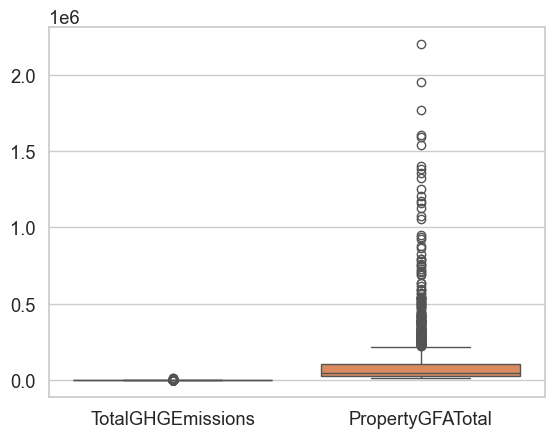

In [1014]:
sns.boxplot(data=df[["TotalGHGEmissions","PropertyGFATotal"]])

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn 
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

### Création mesure ratios de surface

Ratio mesure la part de la surface bâtie principale par rapport à la surface totale déclarée pour le bâtiment

In [1015]:
# Création des ratios de surfaces

df["RateParking"] = round(df.PropertyGFAParking/ df.PropertyGFATotal ,4)

df["RateBuilding"] = round(df["PropertyGFABuilding(s)"] / df["PropertyGFATotal"],4)

df["RatePerFloors"] = round(df.PropertyGFATotal/ df.NumberofFloors ,4)

df["RatePerBuildings"] = round(df.PropertyGFATotal/ df.NumberofBuildings ,4)


In [1016]:
# arrondir pour éviter les valeurs flottantes trop longues
ratio_cols = [col for col in df.columns if col.startswith("Rate")]
df[ratio_cols] = df[ratio_cols].round(4)


In [1017]:
cols_to_drop = ["PropertyGFAParking", "PropertyGFABuilding(s)",
                "SiteEUI(kBtu/sf)",
                "YearBuilt", "SourceEUI(kBtu/sf)",
               "LargestPropertyUseTypeGFA", 
           "SecondLargestPropertyUseTypeGFA",
           "SecondLargestPropertyUseType",
           "ThirdLargestPropertyUseTypeGFA",
           "ThirdLargestPropertyUseType"
               ]

df.drop(columns = cols_to_drop,inplace = True, errors='ignore')

print("Colonnes supprimées avec succès :", cols_to_drop)

Colonnes supprimées avec succès : ['PropertyGFAParking', 'PropertyGFABuilding(s)', 'SiteEUI(kBtu/sf)', 'YearBuilt', 'SourceEUI(kBtu/sf)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType']


### Analyse des Target

Pour rappel, les 2 variables à prédire dans le cadre de notre mission sont :

`TotalGHGEmissions`
`SiteEnergyUse(kBtu)`

Je transforme une variable très étalée (avec des valeurs extrêmes) en une échelle plus compacte, afin de :

- réduire l’influence des outliers,

- rendre la distribution plus “gaussienne”,

- améliorer la stabilité des modèles de régression.

### Transformation log des variables énergétiques

In [1018]:
#Transformation log
for col in ['SiteEnergyUse(kBtu)', 'TotalGHGEmissions', 'PropertyGFATotal']:
    df[f'log_{col}'] = np.log1p(df[col])


In [1019]:
# Réglages généraux du style
sns.set(style="whitegrid", palette="muted", font_scale=1.2)


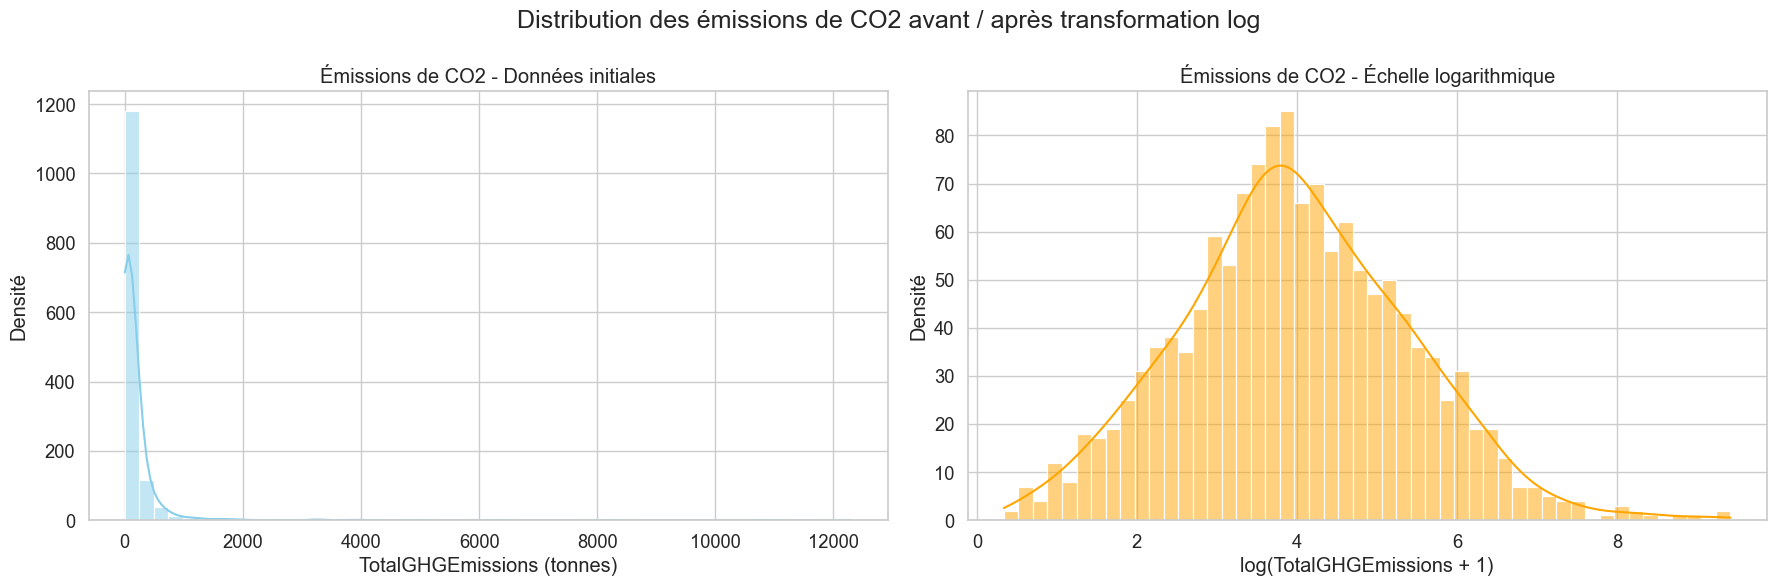

In [934]:
# Distribution des émissions de CO2

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['TotalGHGEmissions'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Émissions de CO2 - Données initiales")
axes[0].set_xlabel("TotalGHGEmissions (tonnes)")
axes[0].set_ylabel("Densité")

sns.histplot(df['log_TotalGHGEmissions'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title("Émissions de CO2 - Échelle logarithmique")
axes[1].set_xlabel("log(TotalGHGEmissions + 1)")
axes[1].set_ylabel("Densité")

plt.suptitle("Distribution des émissions de CO2 avant / après transformation log", fontsize=18)
plt.tight_layout()
plt.show()


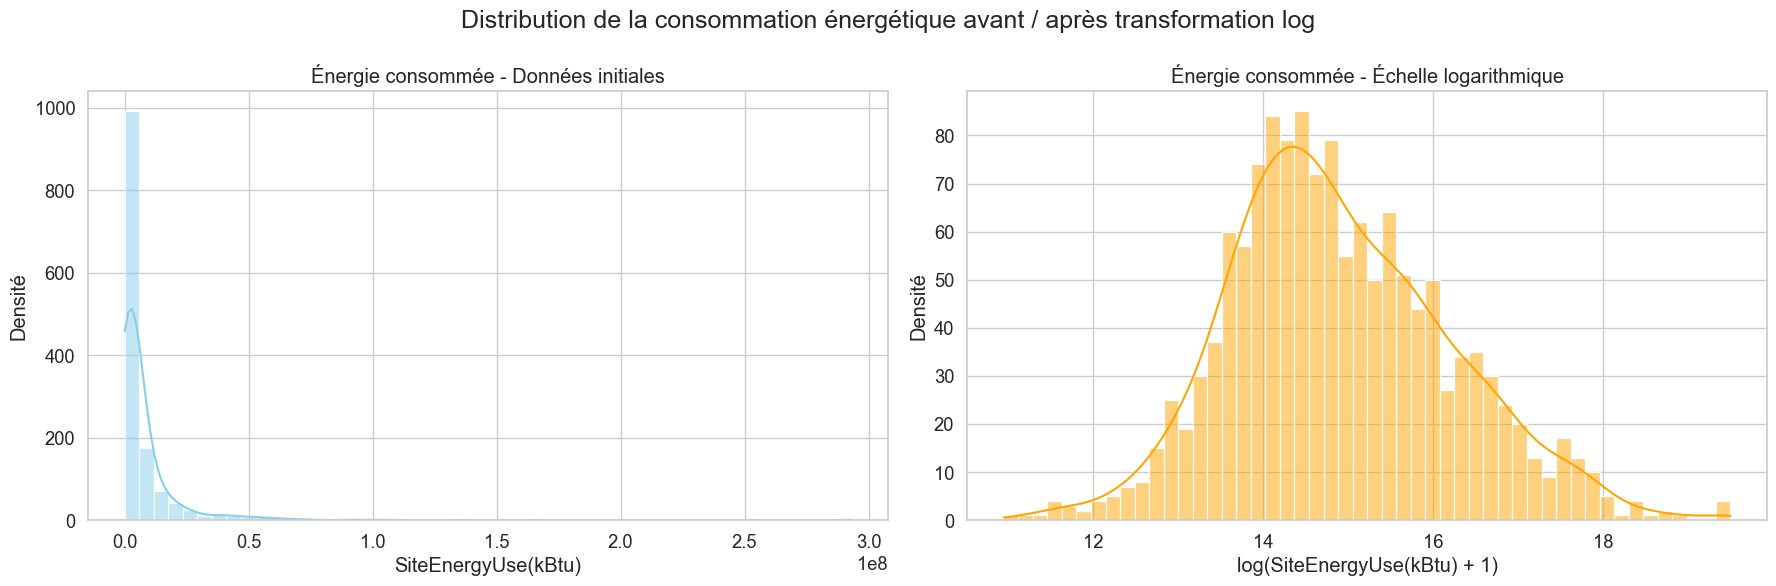

In [935]:
# Distribution de l’énergie consommée

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['SiteEnergyUse(kBtu)'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Énergie consommée - Données initiales")
axes[0].set_xlabel("SiteEnergyUse(kBtu)")
axes[0].set_ylabel("Densité")

sns.histplot(df['log_SiteEnergyUse(kBtu)'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title("Énergie consommée - Échelle logarithmique")
axes[1].set_xlabel("log(SiteEnergyUse(kBtu) + 1)")
axes[1].set_ylabel("Densité")

plt.suptitle("Distribution de la consommation énergétique avant / après transformation log", fontsize=18)
plt.tight_layout()
plt.show()


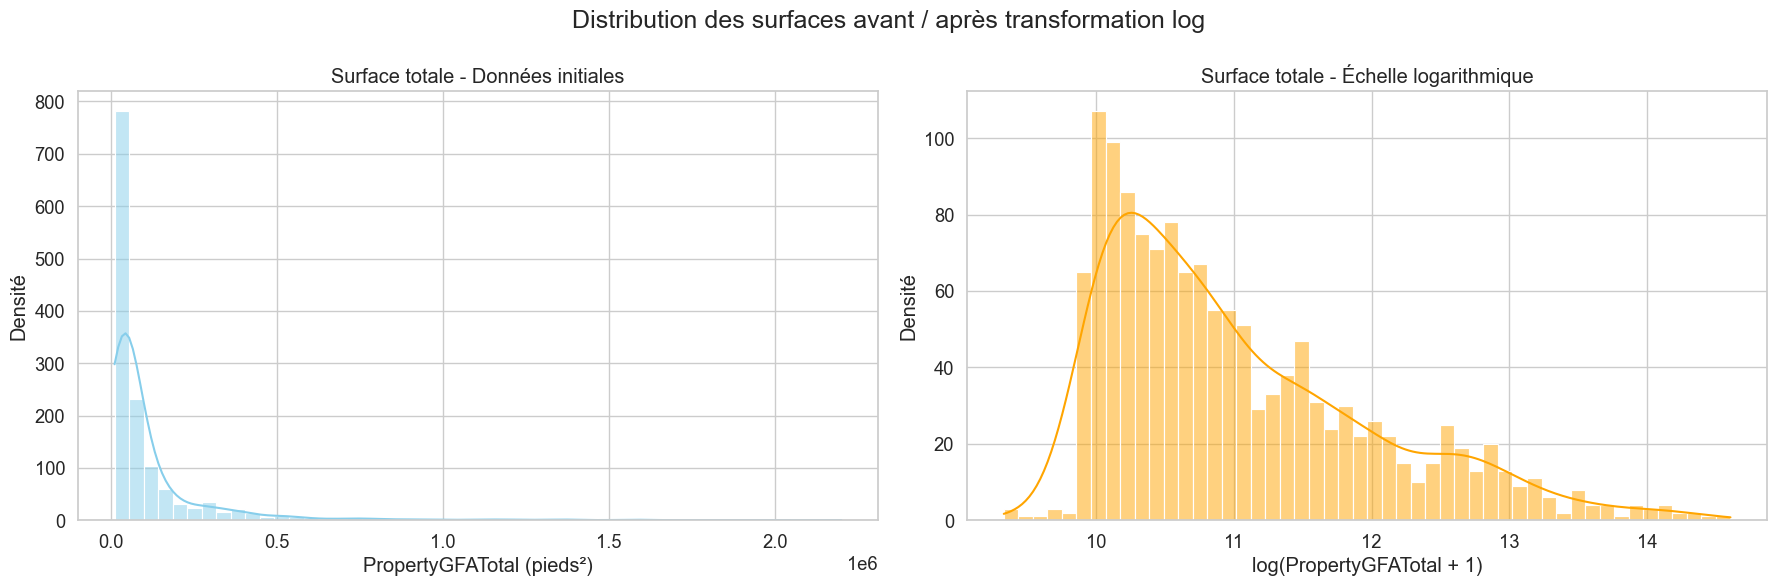

In [936]:
# Distribution des surfaces totales (PropertyGFATotal)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['PropertyGFATotal'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Surface totale - Données initiales")
axes[0].set_xlabel("PropertyGFATotal (pieds²)")
axes[0].set_ylabel("Densité")

sns.histplot(df['log_PropertyGFATotal'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title("Surface totale - Échelle logarithmique")
axes[1].set_xlabel("log(PropertyGFATotal + 1)")
axes[1].set_ylabel("Densité")

plt.suptitle("Distribution des surfaces avant / après transformation log", fontsize=18)
plt.tight_layout()
plt.show()


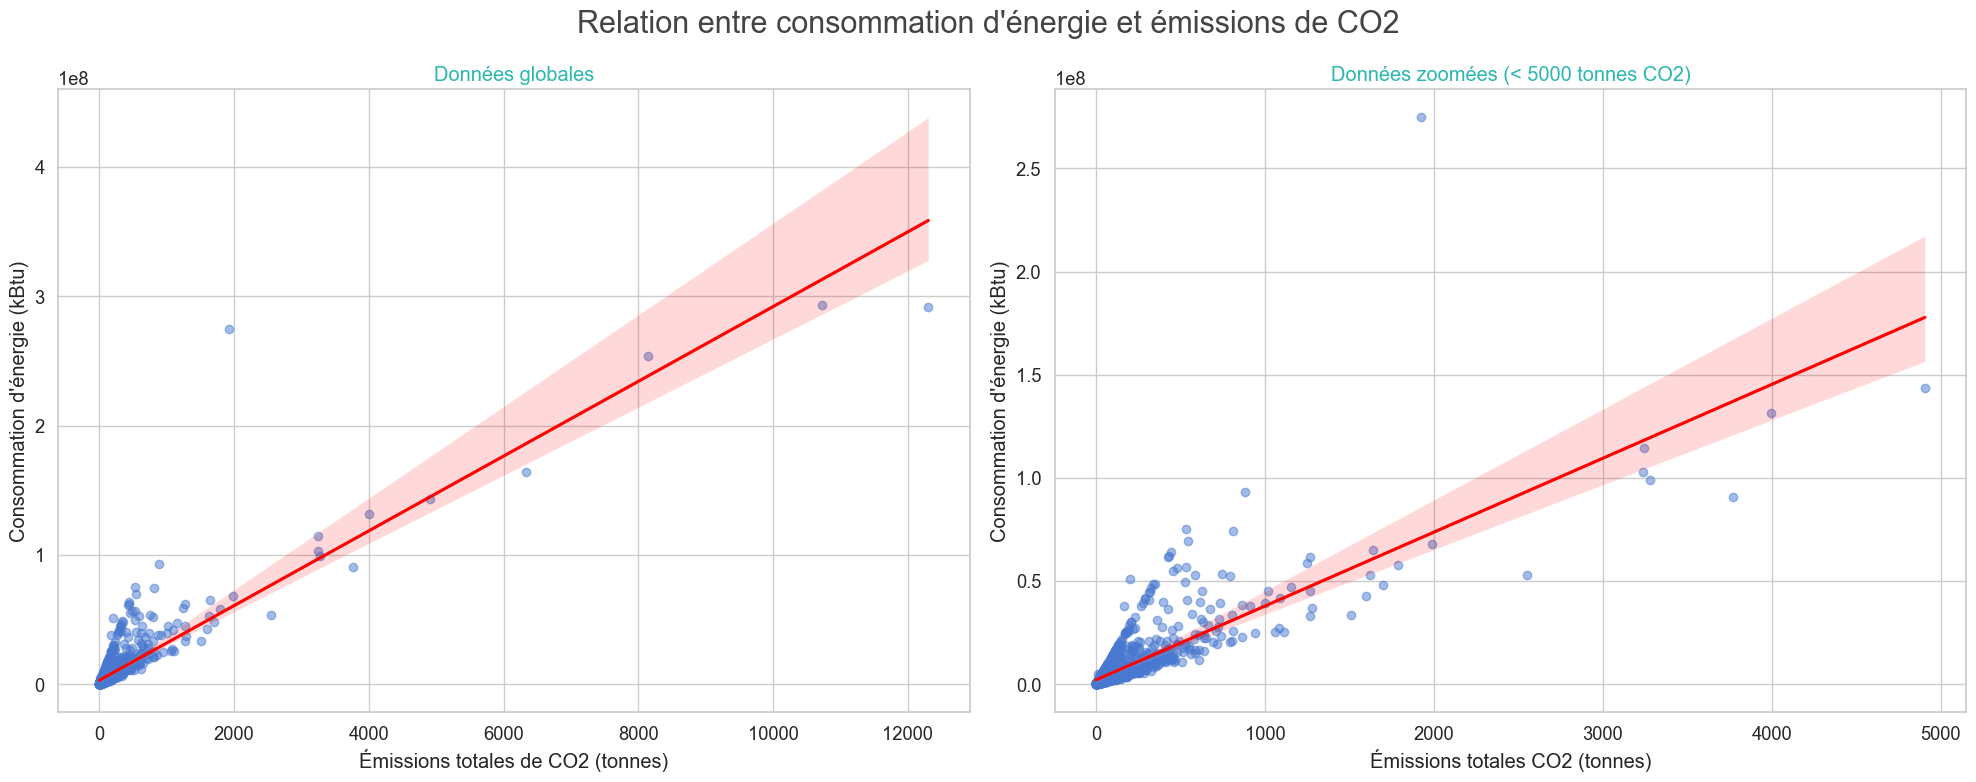

In [937]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Vue globale ---
sns.regplot(
    data=df, 
    x="TotalGHGEmissions", 
    y="SiteEnergyUse(kBtu)", 
    ax=axes[0], 
    scatter_kws={'alpha':0.5}, 
    line_kws={'color':'red'}
)
axes[0].set_title("Données globales", color='#2cb7b0')
axes[0].set_xlabel("Émissions totales de CO2 (tonnes)")
axes[0].set_ylabel("Consommation d'énergie (kBtu)")


# --- Vue zoomée ---
sns.regplot(
    data=df[df['TotalGHGEmissions'] < 5000], 
    x="TotalGHGEmissions", 
    y="SiteEnergyUse(kBtu)", 
    ax=axes[1], 
    scatter_kws={'alpha':0.5}, 
    line_kws={'color':'red'}
)
axes[1].set_title("Données zoomées (< 5000 tonnes CO2)", color='#2cb7b0')
axes[1].set_xlabel("Émissions totales CO2 (tonnes)")
axes[1].set_ylabel("Consommation d'énergie (kBtu)")

plt.suptitle(
    "Relation entre consommation d'énergie et émissions de CO2",
    fontsize=22,
    color="#444"
)
plt.tight_layout()
plt.show()


Ces graphique confirmont parfaitement la relation quasi linéaire entre la consommation d’énergie (`SiteEnergyUse(kBtu)`) et les émissions de CO2 (`TotalGHGEmissions`).

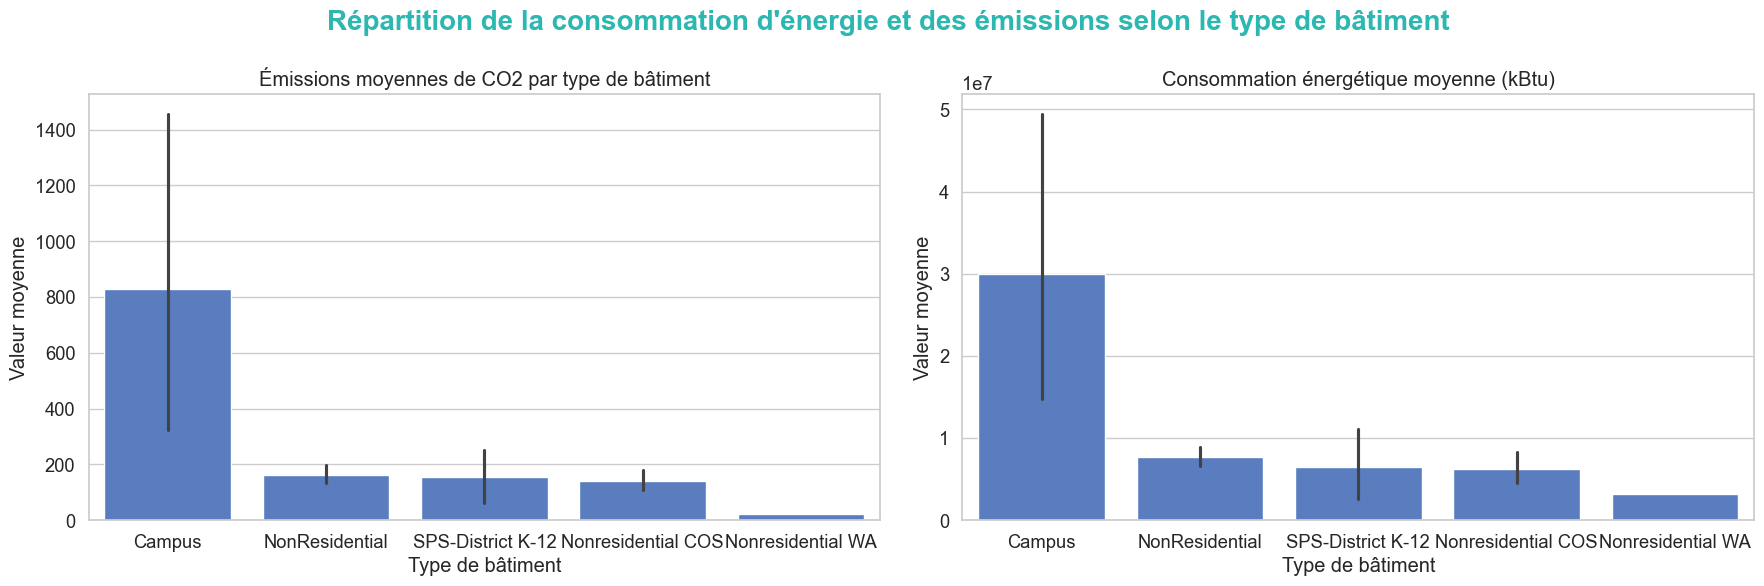

In [938]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    x='BuildingType', y='TotalGHGEmissions',
    data=df, ax=axes[0],
    estimator='mean', order=df.groupby('BuildingType')['TotalGHGEmissions'].mean().sort_values(ascending=False).index
)
axes[0].set_title("Émissions moyennes de CO2 par type de bâtiment")

sns.barplot(
    x='BuildingType', y='SiteEnergyUse(kBtu)',
    data=df, ax=axes[1],
    estimator='mean', order=df.groupby('BuildingType')['SiteEnergyUse(kBtu)'].mean().sort_values(ascending=False).index
)
axes[1].set_title("Consommation énergétique moyenne (kBtu)")

for ax in axes:
    ax.tick_params(axis='x')
    ax.set_xlabel("Type de bâtiment")
    ax.set_ylabel("Valeur moyenne")

plt.suptitle("Répartition de la consommation d'énergie et des émissions selon le type de bâtiment",
             fontsize=20, color='#2cb7b0', weight='bold')
plt.tight_layout()
plt.show()


Sur ces diagrammes en barre, les campus se démarquent largement en terme de consommation et de rejets de CO2.

/var/folders/6w/kyt603rj6b11yw5nslgnnr8c0000gn/T/ipykernel_80209/2045352116.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


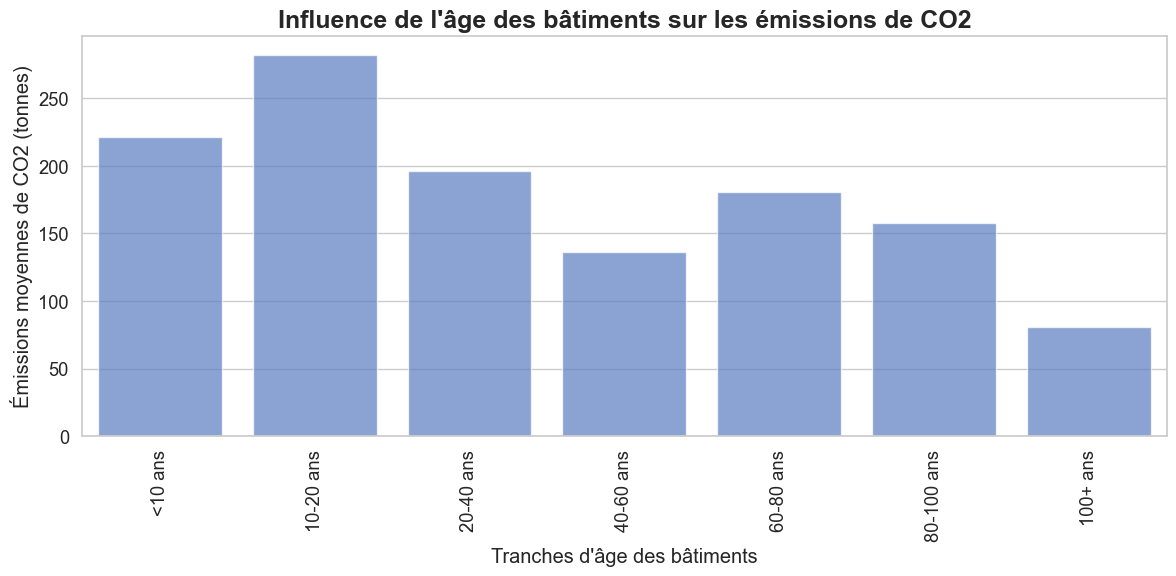

In [939]:
# Création de classes d'âge pour grouper les bâtiments
bins = [0, 10, 20, 40, 60, 80, 100, df['Age'].max()]
labels = ['<10 ans', '10-20 ans', '20-40 ans', '40-60 ans', '60-80 ans', '80-100 ans', '100+ ans']
df['Classe_Age'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

# Visualisation
plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x='Classe_Age', 
    y='TotalGHGEmissions', 
    ci=None,  
    alpha=0.7
)

plt.title("Influence de l'âge des bâtiments sur les émissions de CO2", fontsize=18, weight='bold')
plt.xlabel("Tranches d'âge des bâtiments")
plt.ylabel("Émissions moyennes de CO2 (tonnes)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [940]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1378 entries, 0 to 3375
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      1378 non-null   int64   
 1   BuildingType             1378 non-null   object  
 2   PrimaryPropertyType      1378 non-null   object  
 3   Latitude                 1378 non-null   float64 
 4   Longitude                1378 non-null   float64 
 5   NumberofBuildings        1378 non-null   float64 
 6   NumberofFloors           1378 non-null   int64   
 7   PropertyGFATotal         1378 non-null   int64   
 8   LargestPropertyUseType   1378 non-null   object  
 9   SiteEnergyUse(kBtu)      1378 non-null   float64 
 10  TotalGHGEmissions        1378 non-null   float64 
 11  SteamUse(kBtu)_Usage     1378 non-null   int64   
 12  Electricity(kBtu)_Usage  1378 non-null   int64   
 13  NaturalGas(kBtu)_Usage   1378 non-null   int64   
 14  TotalUseTypeN

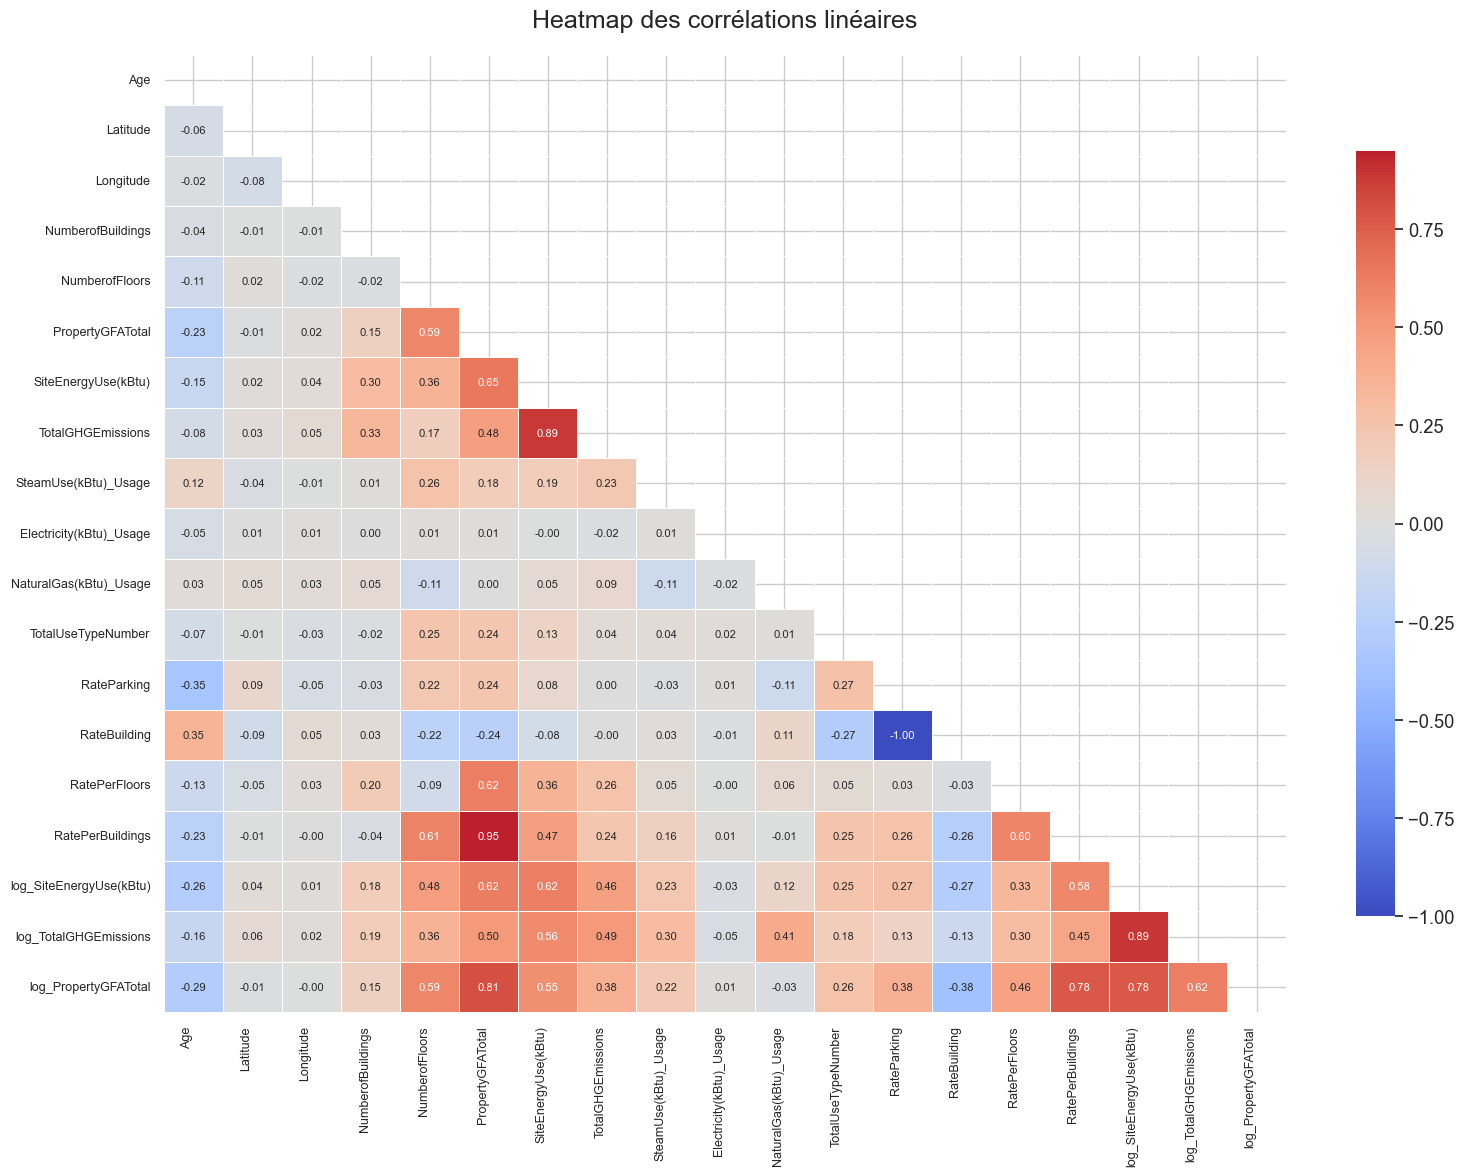

In [1020]:
# Sélection uniquement des colonnes numériques
df_num = df.select_dtypes(include=['number'])

# Calcul de la matrice de corrélation
corr = df_num.corr(method="pearson")

# Masque pour ne pas afficher les doublons
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

# Affichage de la heatmap
plt.figure(figsize=(16, 12))
sns.heatmap( corr,
    mask=mask,
    annot=True,         
    fmt=".2f",          
    cmap="coolwarm",    
    center=0,
    linewidths=0.5,    
    cbar_kws={"shrink": 0.8},  
    annot_kws={"size": 8}      
)
plt.title("Heatmap des corrélations linéaires", fontsize=18, pad=20)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [1021]:
df.drop(["SiteEnergyUse(kBtu)", "TotalGHGEmissions", "PropertyGFATotal"], axis = 1, inplace= True)

In [1022]:
df.drop(["Latitude", "Longitude"], axis = 1, inplace= True)

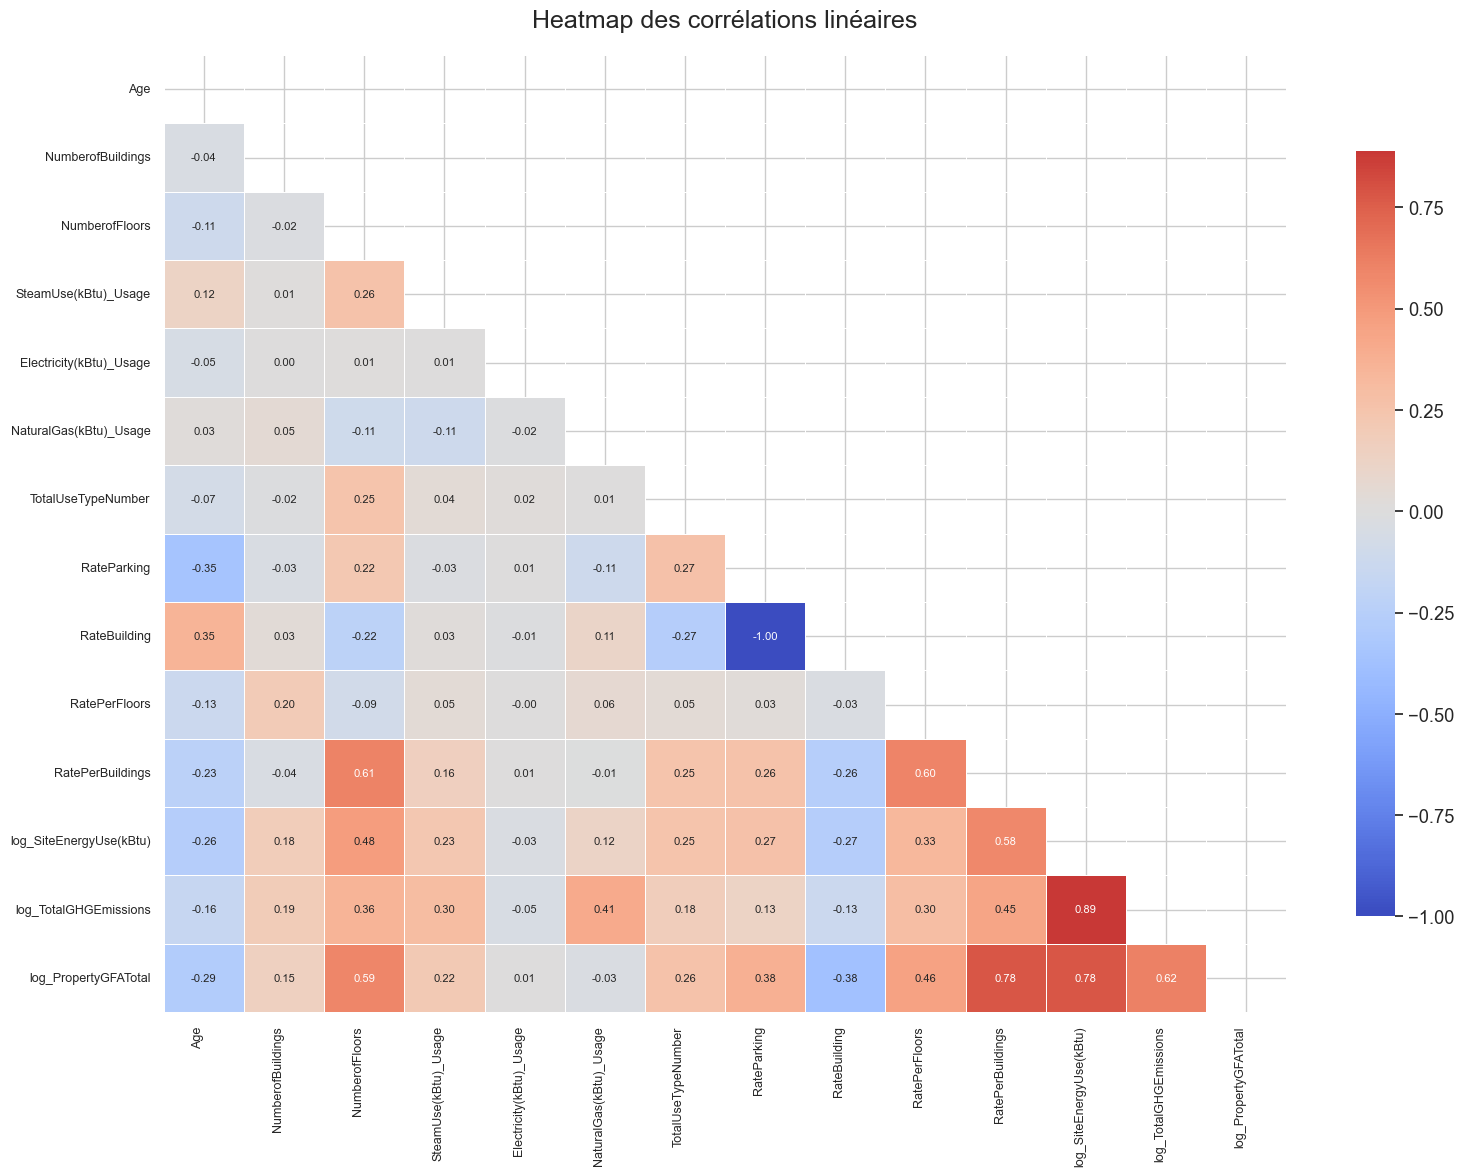

In [1024]:
# Sélection uniquement des colonnes numériques
df_num = df.select_dtypes(include=['number'])

# Calcul de la matrice de corrélation
corr = df_num.corr(method="pearson")

# Masque pour ne pas afficher les doublons
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

# Affichage de la heatmap
plt.figure(figsize=(16, 12))
sns.heatmap( corr,
    mask=mask,
    annot=True,         
    fmt=".2f",          
    cmap="coolwarm",    
    center=0,
    linewidths=0.5,    
    cbar_kws={"shrink": 0.8},  
    annot_kws={"size": 8}      
)
plt.title("Heatmap des corrélations linéaires", fontsize=18, pad=20)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [1025]:
df[['Age', 'RateParking', 'log_SiteEnergyUse(kBtu)', 'log_TotalGHGEmissions']].corr()


,Age,RateParking,log_SiteEnergyUse(kBtu),log_TotalGHGEmissions
Age,1.000000,-0.351192,-0.262897,-0.159222
RateParking,-0.351192,1.000000,0.265973,0.127194
log_SiteEnergyUse(kBtu),-0.262897,0.265973,1.000000,0.889577
log_TotalGHGEmissions,-0.159222,0.127194,0.889577,1.000000


**Interprétation :**

- Les bâtiments récents consomment souvent plus d’énergie (plus grands, plus d’équipements électriques)

- Les bâtiments anciens consomment un peu moins, probablement car :

  Ils sont souvent plus petits, parfois rénovés,ou ont moins d’équipements énergivores ou utilisés différemment (écoles, bureaux légers).

- Plus de parking = plus de consommation énergétique ; typiquement les centres commerciaux, hôpitaux, université (trés énergivores).

### Exportation pour modélisation


In [1026]:
df.reset_index(drop=True, inplace=True)
df.to_csv("building_energy_cleaned.csv", index=False, encoding="utf-8")
print("Dataset exporté avec succès :", df.shape, "lignes et", len(df.columns), "colonnes")

Dataset exporté avec succès : (1378, 17) lignes et 17 colonnes


# Modélisation 

### Import des modules 

### Comparaison de différents modèles supervisés

In [1]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE